
# Subject transition matrices: decade-level outflow and inflow

This notebook studies advisor–student subject transitions using **full decades**.

For decade \(t\), let

$$
M_t(i,j)
=
\text{weighted number of advisor–student edges with advisor subject }i
\text{ and student subject }j.
$$

Two conditional probability matrices are used.

### Forward matrix \(P_t\): outflow from advisor subjects

$$
P_t(i,j)
=
P(\text{student subject}=j\mid \text{advisor subject}=i,\ t).
$$

Rows are advisor subjects and columns are student subjects. Therefore:

- \(P_t(i,i)\): forward self-retention;
- \(1-P_t(i,i)\): outflow rate from subject \(i\) to other subjects;
- row \(i\): destination distribution of students advised from subject \(i\).

### Backward matrix \(Q_t\): inflow into student subjects

$$
Q_t(j,i)
=
P(\text{advisor subject}=i\mid \text{student subject}=j,\ t).
$$

Rows are student subjects and columns are advisor subjects. Therefore:

- \(Q_t(j,j)\): same-subject ancestry rate;
- \(1-Q_t(j,j)\): inflow rate into subject \(j\) from other advisor subjects;
- row \(j\): source distribution of advisors for students in subject \(j\).

The backward matrix is defined as

$$
Q_t = \operatorname{row\_normalize}(M_t^\top).
$$

This is equivalent to column-normalizing \(M_t\) and then transposing it.

### Why decades rather than individual years?

Yearly matrices answer the same questions, but many subject rows have few or no observations in a single year. This produces unstable probabilities, many undefined rows, and visually noisy trends. Decade aggregation sacrifices some time resolution but gives more reliable transition estimates.

This notebook does **not** multiply matrices across decades. Each matrix is treated as a cohort-specific empirical conditional distribution, not as an automatically composable historical dynamical operator.


In [9]:
from pathlib import Path
import ast
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)


## 1. Configuration

The primary analysis uses the original `subject` labels. Genealogy-based imputed subject labels should be reserved for a separately labeled sensitivity analysis because using advisor/descendant information in imputation can mechanically strengthen apparent subject transmission.


In [10]:
# From notebooks/subject_transition-Yilong/ or a similar notebook folder:
DATA_PATH = Path("../../../data/processed/data-new.json")

# Full decades from 1900–1909 through 2010–2019.
START_YEAR = 1900
END_YEAR_EXCLUSIVE = 2020

# Results before 1960 are retained but treated as exploratory because support is sparse.
DISPLAY_START_DECADE = 1960

# False: every valid advisor–student relationship contributes weight 1.
# True: every student contributes total weight 1 across valid advisors.
WEIGHT_MULTIPLE_ADVISORS = False

FOCUS_SUBJECTS = ["62", "68"]
SELECTED_SUBJECTS = FOCUS_SUBJECTS
RECENT_DECADE = 2010

# Minimum row/column support used in ranked probability summaries.
MIN_PROFILE_SUPPORT = 25
TOP_N_PROFILE = 10
TOP_N_FLOWS = 15

In [11]:
DATA_CANDIDATES = [
    DATA_PATH,
    Path("../data/processed/data-new.json"),
    Path("data/processed/data-new.json"),
    Path("../../data/processed/version2_new_dataset_fitted.csv"),
    Path("../data/processed/version2_new_dataset_fitted.csv"),
    Path("data/processed/version2_new_dataset_fitted.csv"),
]

existing_paths = [path for path in DATA_CANDIDATES if path.exists()]

if not existing_paths:
    raise FileNotFoundError(
        "Could not find data-new.json or version2_new_dataset_fitted.csv. "
        "Update DATA_PATH in the configuration cell."
    )

DATA_PATH = existing_paths[0]
print("Loading:", DATA_PATH.resolve())

if DATA_PATH.suffix.lower() == ".json":
    with DATA_PATH.open("r") as file:
        loaded = json.load(file)

    if isinstance(loaded, dict) and "nodes" in loaded:
        nodes = pd.DataFrame(loaded["nodes"])
    elif isinstance(loaded, list):
        nodes = pd.DataFrame(loaded)
    else:
        raise ValueError(
            "The JSON file must contain either a list of records "
            "or a dictionary with a 'nodes' entry."
        )

elif DATA_PATH.suffix.lower() == ".csv":
    nodes = pd.read_csv(DATA_PATH, low_memory=False)

else:
    raise ValueError(f"Unsupported file type: {DATA_PATH.suffix}")

print(f"Rows loaded: {len(nodes):,}")
print("Columns:", list(nodes.columns))

Loading: /Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/data-new.json
Rows loaded: 338,532
Columns: ['id', 'name', 'thesis', 'school', 'country', 'year', 'subject', 'advisors', 'students']



## 2. Clean subjects and construct advisor–student edges


In [12]:
# Standard 2020 MSC top-level codes: 63 subjects
MSC_CODES = [
    "00", "01", "03", "05", "06", "08",
    "11", "12", "13", "14", "15", "16", "17", "18", "19",
    "20", "22", "26", "28", "30", "31", "32", "33", "34", "35", "37", "39",
    "40", "41", "42", "43", "44", "45", "46", "47", "49",
    "51", "52", "53", "54", "55", "57", "58",
    "60", "62", "65", "68",
    "70", "74", "76", "78", "80", "81", "82", "83", "85", "86",
    "90", "91", "92", "93", "94", "97",
]

# Concise labels for every top-level MSC subject.
MSC_LABELS = {
    "00": "00 General",
    "01": "01 History and biography",
    "03": "03 Mathematical logic and foundations",
    "05": "05 Combinatorics",
    "06": "06 Order, lattices, ordered algebra",
    "08": "08 General algebraic systems",
    "11": "11 Number theory",
    "12": "12 Field theory and polynomials",
    "13": "13 Commutative algebra",
    "14": "14 Algebraic geometry",
    "15": "15 Linear and multilinear algebra",
    "16": "16 Associative rings and algebras",
    "17": "17 Nonassociative rings and algebras",
    "18": "18 Category theory and homological algebra",
    "19": "19 K-theory",
    "20": "20 Group theory",
    "22": "22 Topological and Lie groups",
    "26": "26 Real functions",
    "28": "28 Measure and integration",
    "30": "30 Functions of one complex variable",
    "31": "31 Potential theory",
    "32": "32 Several complex variables",
    "33": "33 Special functions",
    "34": "34 Ordinary differential equations",
    "35": "35 Partial differential equations",
    "37": "37 Dynamical systems and ergodic theory",
    "39": "39 Difference and functional equations",
    "40": "40 Sequences, series, summability",
    "41": "41 Approximations and expansions",
    "42": "42 Harmonic analysis",
    "43": "43 Abstract harmonic analysis",
    "44": "44 Integral transforms and operational calculus",
    "45": "45 Integral equations",
    "46": "46 Functional analysis",
    "47": "47 Operator theory",
    "49": "49 Calculus of variations and optimal control",
    "51": "51 Geometry",
    "52": "52 Convex and discrete geometry",
    "53": "53 Differential geometry",
    "54": "54 General topology",
    "55": "55 Algebraic topology",
    "57": "57 Manifolds and cell complexes",
    "58": "58 Global analysis",
    "60": "60 Probability theory and stochastic processes",
    "62": "62 Statistics",
    "65": "65 Numerical analysis",
    "68": "68 Computer science",
    "70": "70 Mechanics of particles and systems",
    "74": "74 Mechanics of deformable solids",
    "76": "76 Fluid mechanics",
    "78": "78 Optics and electromagnetic theory",
    "80": "80 Classical thermodynamics",
    "81": "81 Quantum theory",
    "82": "82 Statistical mechanics and structure of matter",
    "83": "83 Relativity and gravitational theory",
    "85": "85 Astronomy and astrophysics",
    "86": "86 Geophysics",
    "90": "90 Operations research and mathematical programming",
    "91": "91 Game theory, economics, social sciences",
    "92": "92 Biology and other natural sciences",
    "93": "93 Systems theory and control",
    "94": "94 Information, communication, and circuits",
    "97": "97 Mathematics education",
}



def label_subject(code):
    code = str(code).zfill(2)
    return MSC_LABELS.get(code, code)


def parse_id_list(value):
    """Return a deduplicated list of integer IDs."""
    if isinstance(value, (list, tuple, set, np.ndarray)):
        candidates = value

    elif pd.isna(value):
        return []

    elif isinstance(value, str):
        text = value.strip()

        if text in {"", "[]", "nan", "None"}:
            return []

        try:
            parsed = ast.literal_eval(text)
            candidates = (
                parsed
                if isinstance(parsed, (list, tuple, set, np.ndarray))
                else [parsed]
            )
        except (ValueError, SyntaxError, TypeError):
            candidates = re.findall(r"\d+", text)

    else:
        candidates = [value]

    result = []

    for item in candidates:
        try:
            if pd.notna(item):
                result.append(int(item))
        except (TypeError, ValueError):
            pass

    return list(dict.fromkeys(result))


def extract_top_msc_code(value):
    """Extract a valid two-digit top-level MSC code."""
    if pd.isna(value):
        return np.nan

    text = re.sub(r"\.0$", "", str(value).strip())
    match = re.search(r"(?<!\d)(\d{1,2})(?!\d)", text)

    if match is None:
        return np.nan

    code = match.group(1).zfill(2)
    return code if code in MSC_CODES else np.nan

In [13]:
subject_source_column = (
    "subject_code"
    if "subject_code" in nodes.columns
    else "subject"
)

required_columns = {
    "id",
    "year",
    "advisors",
    subject_source_column,
}

missing_columns = required_columns.difference(nodes.columns)

if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

nodes_clean = nodes.copy()

# Use original observed labels only when the fitted dataset also contains imputed labels.
if "predicted_subject_code" in nodes_clean.columns:
    nodes_clean = nodes_clean[
        nodes_clean["predicted_subject_code"].isna()
    ].copy()

nodes_clean["id_clean"] = pd.to_numeric(
    nodes_clean["id"],
    errors="coerce",
)
nodes_clean["year_clean"] = pd.to_numeric(
    nodes_clean["year"],
    errors="coerce",
)
nodes_clean["subject_code"] = (
    nodes_clean[subject_source_column]
    .apply(extract_top_msc_code)
)
nodes_clean["advisor_ids"] = (
    nodes_clean["advisors"]
    .apply(parse_id_list)
)

# Diagnose duplicate IDs with conflicting original subject codes.
id_subject_table = (
    nodes_clean[
        nodes_clean["id_clean"].notna()
        & nodes_clean["subject_code"].isin(MSC_CODES)
    ][["id_clean", "subject_code"]]
    .drop_duplicates()
)

id_conflicts = (
    id_subject_table
    .groupby("id_clean")["subject_code"]
    .nunique()
)

print(
    "IDs with more than one observed subject code:",
    int((id_conflicts > 1).sum()),
)

# Use the modal observed subject if duplicate rows occur for one ID.
id_to_subject = (
    id_subject_table
    .groupby("id_clean")["subject_code"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

student_rows = nodes_clean[
    nodes_clean["id_clean"].notna()
    & nodes_clean["year_clean"].notna()
    & nodes_clean["subject_code"].isin(MSC_CODES)
    & nodes_clean["advisor_ids"].map(len).gt(0)
][
    [
        "id_clean",
        "year_clean",
        "subject_code",
        "advisor_ids",
    ]
].copy()

edges = (
    student_rows
    .explode("advisor_ids")
    .rename(
        columns={
            "id_clean": "student_id",
            "year_clean": "student_year",
            "subject_code": "student_subject",
            "advisor_ids": "advisor_id",
        }
    )
)

edges["student_id"] = edges["student_id"].astype(int)
edges["advisor_id"] = pd.to_numeric(
    edges["advisor_id"],
    errors="coerce",
)
edges = edges.dropna(subset=["advisor_id"]).copy()
edges["advisor_id"] = edges["advisor_id"].astype(int)

# Remove malformed self-links and duplicate student–advisor pairs.
edges = (
    edges[
        edges["student_id"].ne(
            edges["advisor_id"]
        )
    ]
    .drop_duplicates(
        subset=["student_id", "advisor_id"]
    )
    .copy()
)

edges["advisor_subject"] = (
    edges["advisor_id"]
    .map(id_to_subject)
)

edges = edges[
    edges["advisor_subject"].isin(MSC_CODES)
    & edges["student_subject"].isin(MSC_CODES)
].copy()

edges["student_year"] = edges["student_year"].astype(int)

edges = edges[
    edges["student_year"].between(
        START_YEAR,
        END_YEAR_EXCLUSIVE - 1,
        inclusive="both",
    )
].copy()

edges["decade"] = (
    edges["student_year"] // 10
) * 10

if WEIGHT_MULTIPLE_ADVISORS:
    valid_advisor_count = (
        edges.groupby("student_id")["advisor_id"]
        .transform("nunique")
    )
    edges["weight"] = 1.0 / valid_advisor_count
else:
    edges["weight"] = 1.0

print(f"Valid advisor–student edges: {len(edges):,}")
print(f"Unique students represented: {edges['student_id'].nunique():,}")
print(f"Weighted edge total: {edges['weight'].sum():,.1f}")

display(edges.head())

IDs with more than one observed subject code: 0
Valid advisor–student edges: 110,821
Unique students represented: 97,106
Weighted edge total: 110,821.0


,student_id,student_year,student_subject,advisor_id,advisor_subject,decade,weight
59,62,1962,62,20670,49,1960,1.0
236,238,2002,97,78905,03,2000,1.0
241,243,2002,97,78905,03,2000,1.0
248,250,1979,82,83291,81,1970,1.0
279,283,1957,76,255960,74,1950,1.0



## 3. Build the decade count matrices \(M_t\)

Rows are advisor subjects and columns are student subjects. The decade is determined by the student's PhD year.


In [14]:

DECADES = list(range(START_YEAR, END_YEAR_EXCLUSIVE, 10))

def transition_matrix_for_decade(edge_data, decade, codes=MSC_CODES):
    """Return a subject-by-subject weighted transition count matrix."""
    subset = edge_data[edge_data["decade"] == decade]

    matrix = pd.pivot_table(
        subset,
        values="weight",
        index="advisor_subject",
        columns="student_subject",
        aggfunc="sum",
        fill_value=0.0,
    )

    return matrix.reindex(index=codes, columns=codes, fill_value=0.0).astype(float)


M_by_decade = {
    decade: transition_matrix_for_decade(edges, decade)
    for decade in DECADES
}

M_by_decade[1960].iloc[:8, :8]


student_subject,00,01,03,05,06,08,11,12
advisor_subject,,,,,,,,
00,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
01,0.0,8.0,3.0,0.0,1.0,0.0,0.0,0.0
03,1.0,0.0,44.0,1.0,0.0,0.0,1.0,1.0
05,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
06,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
08,0.0,0.0,2.0,0.0,1.0,3.0,0.0,0.0
11,0.0,0.0,0.0,2.0,0.0,0.0,16.0,2.0
12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



## 4. Define the forward matrix \(P_t\) and backward matrix \(Q_t\)

Rows with no observations are left as `NaN`, because their conditional probability distribution is undefined. Treating an unsupported row as all zeros and then computing \(1-P_{ii}\) would incorrectly report a 100% outflow rate.


In [15]:
def normalize_rows(matrix):
    """Normalize nonzero rows to sum to one; leave zero rows undefined."""
    row_totals = matrix.sum(axis=1)

    return matrix.div(
        row_totals.replace(0, np.nan),
        axis=0,
    )


def forward_matrix(matrix):
    """
    P[i, j] = Pr(student subject j | advisor subject i).
    Rows: advisor subjects. Columns: student subjects.
    """
    return normalize_rows(matrix)


def backward_matrix(matrix):
    """
    Q[j, i] = Pr(advisor subject i | student subject j).
    Rows: student subjects. Columns: advisor subjects.
    """
    return normalize_rows(matrix.T)


P_by_decade = {
    decade: forward_matrix(matrix)
    for decade, matrix in M_by_decade.items()
}

Q_by_decade = {
    decade: backward_matrix(matrix)
    for decade, matrix in M_by_decade.items()
}


def supported_row_sums(matrix):
    sums = matrix.sum(axis=1, min_count=1)
    return sums[sums.notna()]


for decade in DECADES:
    matrix = M_by_decade[decade]

    if matrix.shape != (len(MSC_CODES), len(MSC_CODES)):
        raise AssertionError(
            f"M_{decade} has shape {matrix.shape}, "
            f"not {(len(MSC_CODES), len(MSC_CODES))}."
        )

    for name, probability_matrix in {
        "P": P_by_decade[decade],
        "Q": Q_by_decade[decade],
    }.items():
        sums = supported_row_sums(probability_matrix)

        if len(sums) and not np.allclose(
            sums.to_numpy(),
            1.0,
        ):
            raise AssertionError(
                f"{name}_{decade} has a supported row "
                "that does not sum to one."
            )

    # Q should equal column-normalizing M and then transposing.
    column_totals = (
        matrix.sum(axis=0)
        .replace(0, np.nan)
    )

    q_check = (
        matrix
        .div(column_totals, axis=1)
        .T
    )

    if not np.allclose(
        Q_by_decade[decade].fillna(0),
        q_check.fillna(0),
    ):
        raise AssertionError(
            f"Q_{decade} failed the column-normalization check."
        )

print("All matrices passed shape and normalization checks.")

All matrices passed shape and normalization checks.



## 5. Data-support diagnostics

These quantities should accompany probability trends. A decade with few edges or many unsupported subjects will produce less stable estimates.


In [16]:
def support_summary(matrix):
    row_totals = matrix.sum(axis=1)
    column_totals = matrix.sum(axis=0)

    return {
        "weighted_edge_total": float(
            matrix.to_numpy().sum()
        ),
        "active_advisor_subjects": int(
            (row_totals > 0).sum()
        ),
        "active_student_subjects": int(
            (column_totals > 0).sum()
        ),
        "zero_advisor_rows": int(
            (row_totals == 0).sum()
        ),
        "zero_student_columns": int(
            (column_totals == 0).sum()
        ),
        "advisor_rows_below_10": int(
            (
                (row_totals > 0)
                & (row_totals < 10)
            ).sum()
        ),
        "student_columns_below_10": int(
            (
                (column_totals > 0)
                & (column_totals < 10)
            ).sum()
        ),
        "matrix_density": float(
            (matrix.to_numpy() > 0).mean()
        ),
    }


support_df = pd.DataFrame(
    {
        decade: support_summary(matrix)
        for decade, matrix in M_by_decade.items()
    }
).T

support_df.index.name = "decade"

display(
    support_df.loc[
        DISPLAY_START_DECADE:
    ].round(3)
)

,weighted_edge_total,active_advisor_subjects,active_student_subjects,zero_advisor_rows,zero_student_columns,advisor_rows_below_10,student_columns_below_10,matrix_density
decade,,,,,,,,
1960,3500.0,60.0,60.0,3.0,3.0,21.0,20.0,0.132
1970,6092.0,63.0,62.0,0.0,1.0,10.0,9.0,0.183
1980,9122.0,63.0,63.0,0.0,0.0,5.0,6.0,0.211
1990,16136.0,63.0,63.0,0.0,0.0,2.0,4.0,0.266
2000,28543.0,63.0,63.0,0.0,0.0,1.0,0.0,0.349
2010,44450.0,63.0,63.0,0.0,0.0,0.0,0.0,0.424


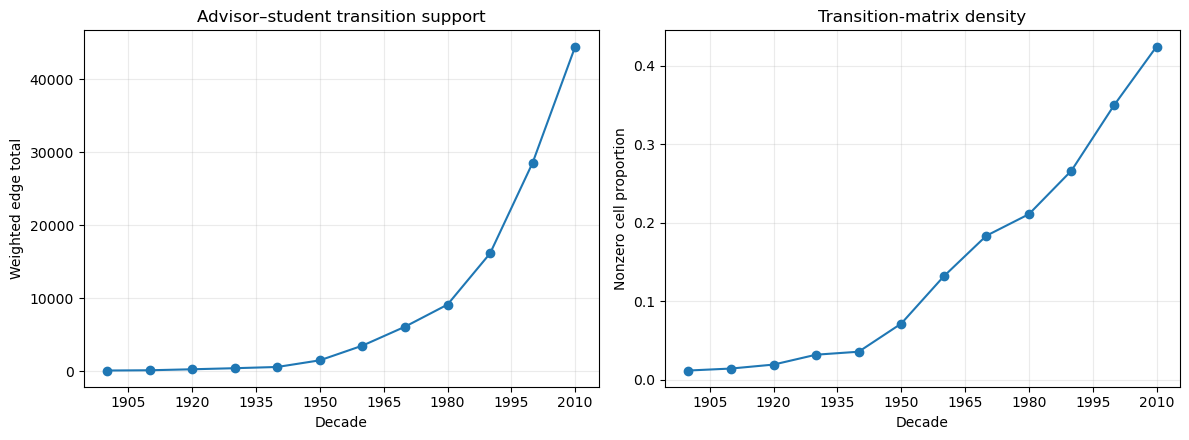

In [17]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

axes[0].plot(
    support_df.index,
    support_df["weighted_edge_total"],
    marker="o",
)
axes[0].set_ylabel("Weighted edge total")
axes[0].set_title("Advisor–student transition support")

axes[1].plot(
    support_df.index,
    support_df["matrix_density"],
    marker="o",
)
axes[1].set_ylabel("Nonzero cell proportion")
axes[1].set_title("Transition-matrix density")

for axis in axes:
    axis.set_xlabel("Decade")
    axis.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )
    axis.grid(alpha=0.25)

fig.tight_layout()
plt.show()

### 5.1 Transition overview in the selected decade

The three heatmaps answer different questions:

- $M_t$: where the largest transition volumes occur;
- $P_t$: destinations conditional on advisor subject;
- $Q_t$: sources conditional on student subject.

To keep labels readable, the plots use the most strongly supported subjects in the selected decade, while always including Statistics and Computer science.

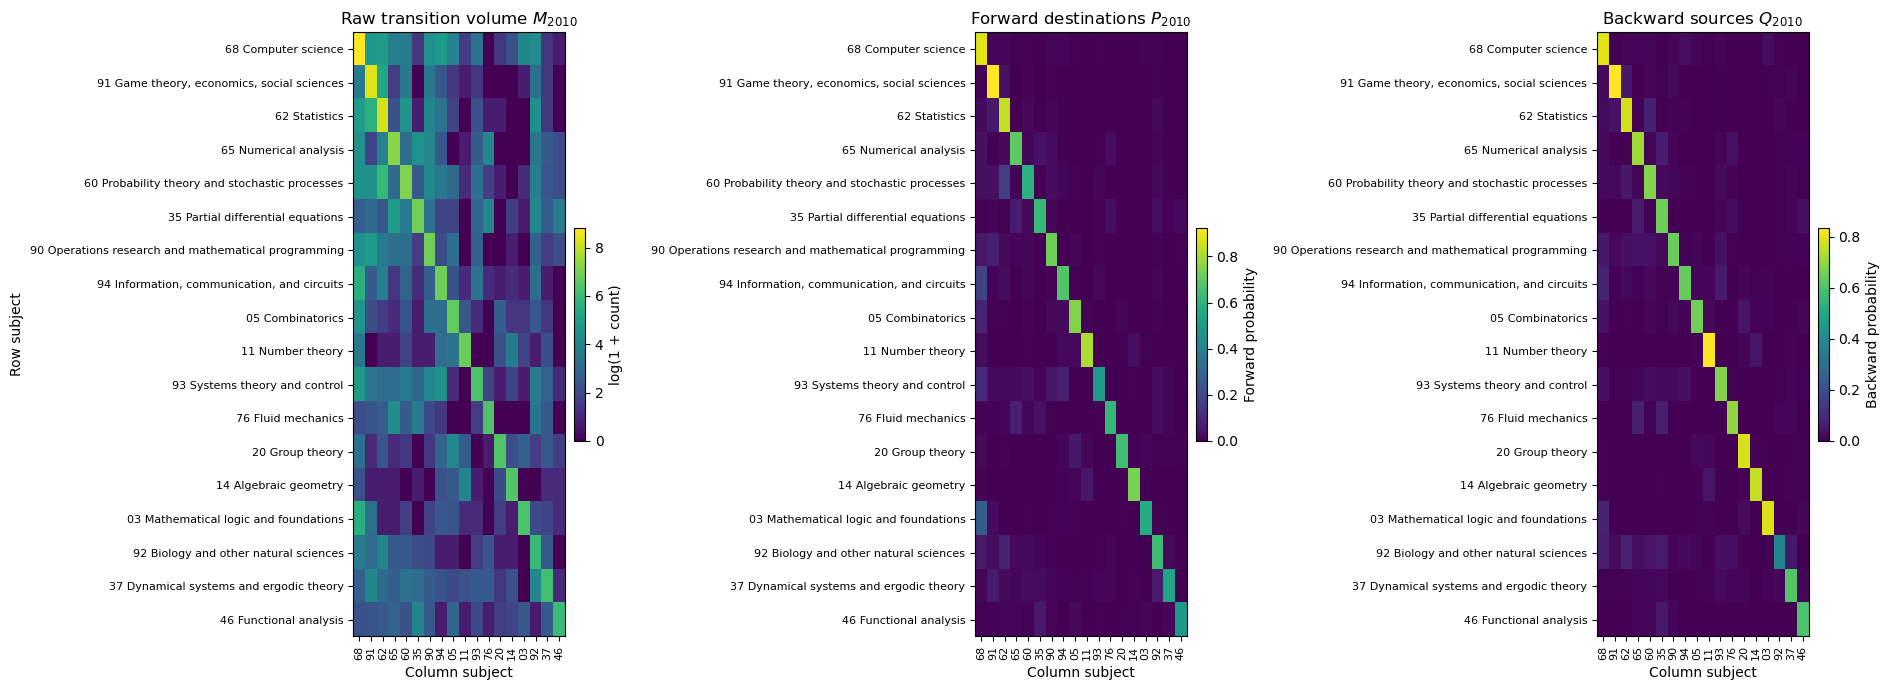

In [18]:
def top_supported_subjects(
    matrix,
    top_n=18,
    always_include=FOCUS_SUBJECTS,
):
    support = (
        matrix.sum(axis=1)
        + matrix.sum(axis=0)
    ).sort_values(ascending=False)

    selected = list(
        support.head(top_n).index
    )

    for subject in always_include:
        if subject not in selected:
            selected.append(subject)

    return selected


def plot_transition_overview(
    decade=RECENT_DECADE,
    top_n=18,
):
    matrix = M_by_decade[decade]
    selected = top_supported_subjects(
        matrix,
        top_n=top_n,
    )

    panels = [
        (
            np.log1p(
                matrix.loc[
                    selected,
                    selected,
                ]
            ),
            "log(1 + count)",
            f"Raw transition volume $M_{{{decade}}}$",
        ),
        (
            P_by_decade[decade].loc[
                selected,
                selected,
            ],
            "Forward probability",
            f"Forward destinations $P_{{{decade}}}$",
        ),
        (
            Q_by_decade[decade].loc[
                selected,
                selected,
            ],
            "Backward probability",
            f"Backward sources $Q_{{{decade}}}$",
        ),
    ]

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(19, 7),
    )

    labels = [
        label_subject(code)
        for code in selected
    ]

    for axis, (
        data,
        colorbar_label,
        title,
    ) in zip(axes, panels):
        image = axis.imshow(
            data.fillna(0).to_numpy(),
            aspect="auto",
        )

        fig.colorbar(
            image,
            ax=axis,
            fraction=0.046,
            pad=0.04,
            label=colorbar_label,
        )

        axis.set_xticks(
            np.arange(len(selected))
        )
        axis.set_xticklabels(
            selected,
            rotation=90,
            fontsize=8,
        )

        axis.set_yticks(
            np.arange(len(selected))
        )
        axis.set_yticklabels(
            labels,
            fontsize=8,
        )

        axis.set_xlabel("Column subject")
        axis.set_title(title)

    axes[0].set_ylabel("Row subject")
    fig.tight_layout()
    plt.show()


plot_transition_overview()

### 5.2 Largest off-diagonal transition volumes

Large raw flows can reflect both genuine affinity and the overall size of the two subjects. Section 11 later compares observed counts with an independence-model expectation.

In [19]:
def off_diagonal_flow_table(
    matrix,
    top_n=TOP_N_FLOWS,
):
    long = (
        matrix
        .rename_axis("advisor_subject")
        .reset_index()
        .melt(
            id_vars="advisor_subject",
            var_name="student_subject",
            value_name="count",
        )
    )

    long = long[
        long["advisor_subject"].ne(
            long["student_subject"]
        )
        & long["count"].gt(0)
    ].copy()

    total = matrix.to_numpy().sum()

    long["share_of_all_edges"] = (
        long["count"] / total
    )
    long["advisor_label"] = (
        long["advisor_subject"]
        .map(label_subject)
    )
    long["student_label"] = (
        long["student_subject"]
        .map(label_subject)
    )

    return (
        long.sort_values(
            "count",
            ascending=False,
        )
        .head(top_n)
        .reset_index(drop=True)
    )


top_flows = off_diagonal_flow_table(
    M_by_decade[RECENT_DECADE]
)

display(
    top_flows[
        [
            "advisor_label",
            "student_label",
            "count",
            "share_of_all_edges",
        ]
    ].round(4)
)

,advisor_label,student_label,count,share_of_all_edges
0,60 Probability theory and stochastic processes,62 Statistics,364.0,0.0082
1,62 Statistics,"91 Game theory, economics, social sciences",285.0,0.0064
2,03 Mathematical logic and foundations,68 Computer science,263.0,0.0059
3,"94 Information, communication, and circuits",68 Computer science,257.0,0.0058
4,"91 Game theory, economics, social sciences",62 Statistics,199.0,0.0045
5,62 Statistics,68 Computer science,127.0,0.0029
6,68 Computer science,62 Statistics,125.0,0.0028
7,35 Partial differential equations,65 Numerical analysis,124.0,0.0028
8,93 Systems theory and control,68 Computer science,123.0,0.0028
9,68 Computer science,"94 Information, communication, and circuits",119.0,0.0027



## 6. Subject-level retention, outflow, and inflow rates

For subject \(i\):

$$
\text{forward retention}_i(t)=P_t(i,i),
\qquad
\text{outflow rate}_i(t)=1-P_t(i,i),
$$

and

$$
\text{same-subject ancestry}_i(t)=Q_t(i,i),
\qquad
\text{inflow rate}_i(t)=1-Q_t(i,i).
$$

The outflow rate is the proportion of students advised from subject \(i\) who move to another subject.

The inflow rate is the proportion of students in subject \(i\) whose advisors came from another subject.


In [20]:

def diagonal_frame(matrices):
    frame = pd.DataFrame(
        {
            decade: pd.Series(
                np.diag(matrix.to_numpy()),
                index=matrix.index,
            )
            for decade, matrix in matrices.items()
        }
    ).T
    frame.index.name = "decade"
    frame.columns.name = "subject"
    return frame


forward_retention_df = diagonal_frame(P_by_decade)
same_subject_ancestry_df = diagonal_frame(Q_by_decade)

outflow_rate_df = 1.0 - forward_retention_df
inflow_rate_df = 1.0 - same_subject_ancestry_df

# Unsupported subject-decades remain NaN rather than being reported as 100%.
outflow_rate_df.head()


subject,00,01,03,05,06,08,11,12,13,14,15,16,17,18,19,20,22,26,28,30,31,32,33,34,35,37,39,40,41,42,43,44,45,46,47,49,51,52,53,54,55,57,58,60,62,65,68,70,74,76,78,80,81,82,83,85,86,90,91,92,93,94,97
decade,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1900,0.5,0.333333,NaN,NaN,NaN,NaN,1.00,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.0,1.000000,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.00,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.571429,0.666667,0.300000,1.00,NaN,0.800000,NaN,0.00,NaN,NaN,0.064516,0.571429,NaN,NaN,NaN
1910,1.0,1.000000,0.00,NaN,NaN,NaN,0.00,NaN,NaN,0.666667,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,1.000000,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,0.545455,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,0.500000,1.000000,0.437500,1.00,1.000000,0.333333,NaN,0.25,1.000000,NaN,0.029412,0.000000,1.0,NaN,0.0
1920,0.0,0.400000,0.00,NaN,NaN,1.000000,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,1.0,NaN,1.000000,NaN,NaN,1.0,1.0,1.0,NaN,NaN,1.00,NaN,1.0,NaN,NaN,NaN,1.000000,NaN,NaN,0.714286,NaN,1.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.500000,0.500000,0.75,0.375000,0.444444,NaN,0.05,0.000000,NaN,0.064220,0.533333,NaN,NaN,0.0
1930,1.0,0.400000,0.00,NaN,1.0,0.666667,0.25,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.8,NaN,0.500000,NaN,NaN,1.0,0.8,1.0,NaN,NaN,0.75,NaN,1.0,NaN,NaN,NaN,0.529412,NaN,1.0,0.857143,NaN,0.600000,1.0,NaN,NaN,NaN,1.000,1.0,NaN,NaN,0.888889,0.500000,0.363636,0.703704,1.00,0.344828,0.551724,1.0,0.00,NaN,NaN,0.017544,0.344828,NaN,NaN,0.0
1940,1.0,0.500000,0.25,NaN,NaN,0.500000,0.60,NaN,NaN,0.500000,1.0,NaN,NaN,NaN,NaN,0.428571,NaN,1.0,1.0,0.769231,1.0,1.0,NaN,0.5,1.0,NaN,NaN,1.00,1.0,1.0,NaN,NaN,NaN,0.250000,NaN,1.0,0.583333,NaN,0.333333,1.0,1.0,NaN,NaN,0.875,0.4,NaN,NaN,0.769231,0.388889,0.466667,0.472222,1.00,0.377778,0.500000,NaN,0.10,0.333333,1.0,0.030928,0.104167,0.5,0.333333,0.0


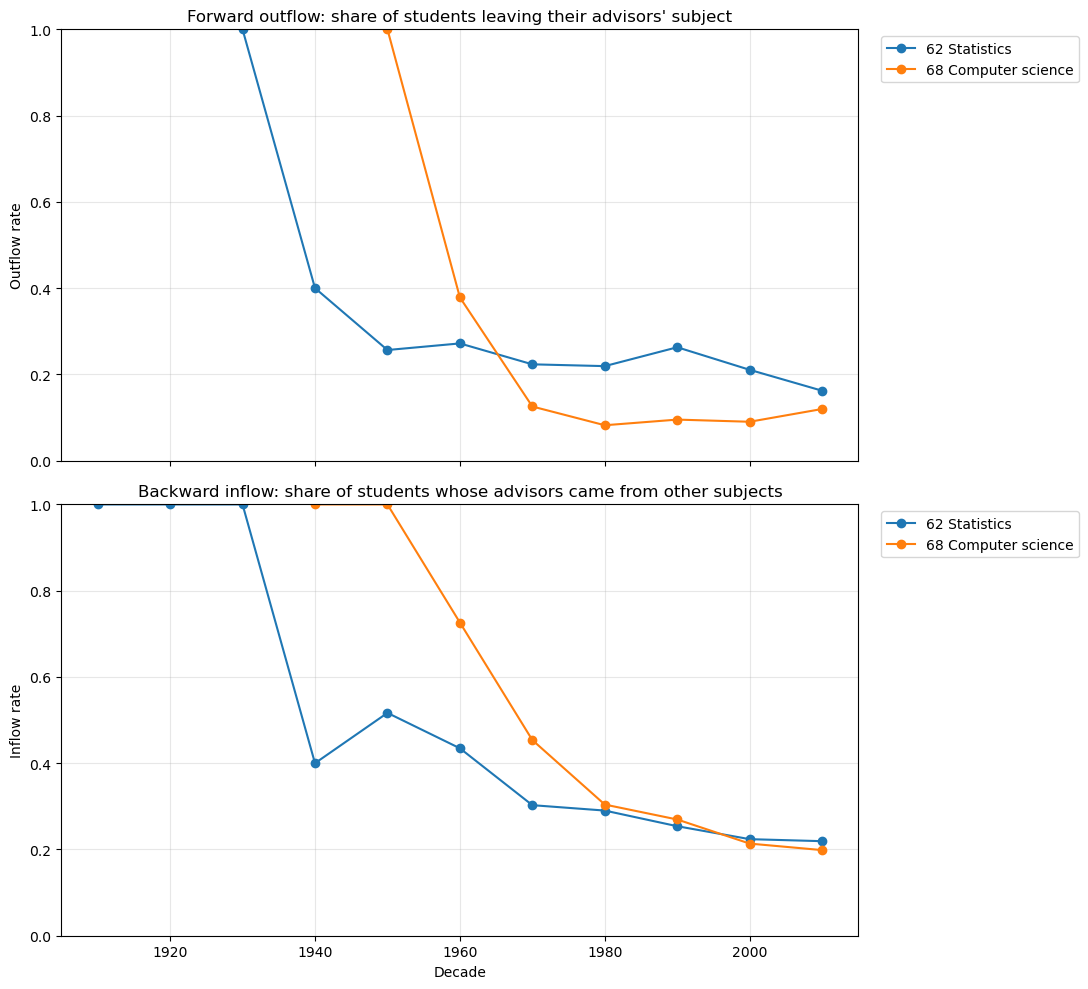

In [21]:

def plot_subject_rates(subjects=SELECTED_SUBJECTS):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(11, 10),
        sharex=True,
    )

    for subject in subjects:
        if subject in outflow_rate_df.columns:
            axes[0].plot(
                outflow_rate_df.index,
                outflow_rate_df[subject],
                marker="o",
                label=label_subject(subject),
            )

        if subject in inflow_rate_df.columns:
            axes[1].plot(
                inflow_rate_df.index,
                inflow_rate_df[subject],
                marker="o",
                label=label_subject(subject),
            )

    axes[0].set_ylabel("Outflow rate")
    axes[0].set_title(
        "Forward outflow: share of students leaving their advisors' subject"
    )

    axes[1].set_xlabel("Decade")
    axes[1].set_ylabel("Inflow rate")
    axes[1].set_title(
        "Backward inflow: share of students whose advisors came from other subjects"
    )

    for axis in axes:
        axis.set_ylim(0, 1)
        axis.grid(alpha=0.3)
        axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.tight_layout()
    plt.show()


plot_subject_rates()


### 6.1 Retention rankings in the 2010s

The ranking excludes subjects with fewer than `MIN_PROFILE_SUPPORT` advisor or student edges. This avoids interpreting extreme probabilities supported by only a handful of observations.

In [22]:
def subject_rate_table(decade):
    matrix = M_by_decade[decade]

    result = pd.DataFrame(
        {
            "subject": MSC_CODES,
            "forward_retention": (
                forward_retention_df
                .loc[decade]
                .reindex(MSC_CODES)
                .to_numpy()
            ),
            "outflow_rate": (
                outflow_rate_df
                .loc[decade]
                .reindex(MSC_CODES)
                .to_numpy()
            ),
            "same_subject_ancestry": (
                same_subject_ancestry_df
                .loc[decade]
                .reindex(MSC_CODES)
                .to_numpy()
            ),
            "inflow_rate": (
                inflow_rate_df
                .loc[decade]
                .reindex(MSC_CODES)
                .to_numpy()
            ),
            "advisor_edge_total": (
                matrix.sum(axis=1)
                .reindex(MSC_CODES)
                .to_numpy()
            ),
            "student_edge_total": (
                matrix.sum(axis=0)
                .reindex(MSC_CODES)
                .to_numpy()
            ),
        }
    )

    result["subject_label"] = (
        result["subject"]
        .map(label_subject)
    )

    return result


rate_profile = subject_rate_table(
    RECENT_DECADE
)

supported_rate_profile = rate_profile[
    rate_profile["advisor_edge_total"].ge(
        MIN_PROFILE_SUPPORT
    )
    & rate_profile["student_edge_total"].ge(
        MIN_PROFILE_SUPPORT
    )
].copy()

print("Highest forward self-retention")
display(
    supported_rate_profile.nlargest(
        10,
        "forward_retention",
    )[
        [
            "subject_label",
            "forward_retention",
            "advisor_edge_total",
        ]
    ].round(3)
)

print("Lowest forward self-retention")
display(
    supported_rate_profile.nsmallest(
        10,
        "forward_retention",
    )[
        [
            "subject_label",
            "forward_retention",
            "advisor_edge_total",
        ]
    ].round(3)
)

Highest forward self-retention


,subject_label,forward_retention,advisor_edge_total
62,97 Mathematics education,0.950,497.0
58,"91 Game theory, economics, social sciences",0.924,4684.0
46,68 Computer science,0.880,7645.0
44,62 Statistics,0.838,4586.0
6,11 Number theory,0.808,1111.0
3,05 Combinatorics,0.748,1078.0
9,14 Algebraic geometry,0.737,862.0
55,85 Astronomy and astrophysics,0.734,380.0
57,90 Operations research and mathematical progra...,0.718,1444.0
45,65 Numerical analysis,0.694,2007.0


Lowest forward self-retention


,subject_label,forward_retention,advisor_edge_total
7,12 Field theory and polynomials,0.070,43.0
32,45 Integral equations,0.083,36.0
18,28 Measure and integration,0.179,39.0
0,00 General,0.185,92.0
42,58 Global analysis,0.201,169.0
26,39 Difference and functional equations,0.243,37.0
4,"06 Order, lattices, ordered algebra",0.245,98.0
30,43 Abstract harmonic analysis,0.248,101.0
5,08 General algebraic systems,0.250,80.0
16,22 Topological and Lie groups,0.264,140.0


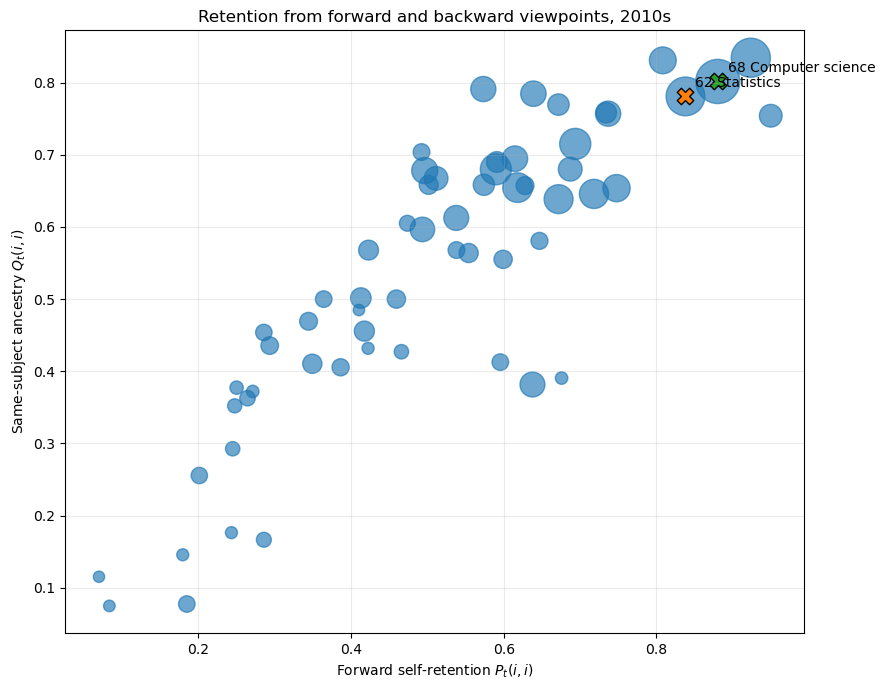

In [23]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.scatter(
    supported_rate_profile[
        "forward_retention"
    ],
    supported_rate_profile[
        "same_subject_ancestry"
    ],
    s=np.sqrt(
        supported_rate_profile[
            "advisor_edge_total"
        ]
        + supported_rate_profile[
            "student_edge_total"
        ]
    ) * 8,
    alpha=0.65,
)

for subject in FOCUS_SUBJECTS:
    row = supported_rate_profile[
        supported_rate_profile[
            "subject"
        ].eq(subject)
    ]

    if not row.empty:
        x = row[
            "forward_retention"
        ].iloc[0]
        y = row[
            "same_subject_ancestry"
        ].iloc[0]

        ax.scatter(
            [x],
            [y],
            s=140,
            marker="X",
            edgecolor="black",
        )

        ax.annotate(
            label_subject(subject),
            (x, y),
            xytext=(7, 7),
            textcoords="offset points",
        )

ax.set_xlabel(
    "Forward self-retention $P_t(i,i)$"
)
ax.set_ylabel(
    "Same-subject ancestry $Q_t(i,i)$"
)
ax.set_title(
    "Retention from forward and backward viewpoints, "
    f"{RECENT_DECADE}s"
)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 7. Raw flow counts

The probability matrices answer conditional questions. The count matrix answers volume questions.

- Raw outflow count from subject \(i\): off-diagonal sum of row \(i\).
- Raw inflow count into subject \(i\): off-diagonal sum of column \(i\).
- Net inflow: raw inflow minus raw outflow.

These counts should not be called rates.


In [24]:

def flow_count_summary(matrix):
    diagonal = pd.Series(
        np.diag(matrix.to_numpy()),
        index=matrix.index,
        dtype=float,
    )

    raw_outflow = matrix.sum(axis=1) - diagonal
    raw_inflow = matrix.sum(axis=0) - diagonal

    return pd.DataFrame(
        {
            "raw_inflow_count": raw_inflow,
            "raw_outflow_count": raw_outflow,
            "net_inflow_count": raw_inflow - raw_outflow,
            "same_subject_count": diagonal,
            "advisor_edge_total": matrix.sum(axis=1),
            "student_edge_total": matrix.sum(axis=0),
        }
    )


flow_counts_by_decade = {
    decade: flow_count_summary(matrix)
    for decade, matrix in M_by_decade.items()
}

recent_flow_ranking = (
    flow_counts_by_decade[
        RECENT_DECADE
    ]
    .assign(
        subject_label=lambda frame: [
            label_subject(code)
            for code in frame.index
        ]
    )
)

print("Largest net inflows")
display(
    recent_flow_ranking.nlargest(
        10,
        "net_inflow_count",
    )[
        [
            "subject_label",
            "raw_inflow_count",
            "raw_outflow_count",
            "net_inflow_count",
        ]
    ]
)

print("Largest net outflows")
display(
    recent_flow_ranking.nsmallest(
        10,
        "net_inflow_count",
    )[
        [
            "subject_label",
            "raw_inflow_count",
            "raw_outflow_count",
            "net_inflow_count",
        ]
    ]
)


Largest net inflows


,subject_label,raw_inflow_count,raw_outflow_count,net_inflow_count
68,68 Computer science,1667.0,915.0,752.0
91,"91 Game theory, economics, social sciences",859.0,358.0,501.0
92,92 Biology and other natural sciences,627.0,220.0,407.0
62,62 Statistics,1079.0,743.0,336.0
90,90 Operations research and mathematical progra...,569.0,407.0,162.0
05,05 Combinatorics,427.0,272.0,155.0
97,97 Mathematics education,154.0,25.0,129.0
00,00 General,202.0,75.0,127.0
94,"94 Information, communication, and circuits",547.0,472.0,75.0
18,18 Category theory and homological algebra,111.0,53.0,58.0


Largest net outflows


,subject_label,raw_inflow_count,raw_outflow_count,net_inflow_count
93,93 Systems theory and control,265.0,566.0,-301.0
60,60 Probability theory and stochastic processes,584.0,863.0,-279.0
03,03 Mathematical logic and foundations,148.0,417.0,-269.0
20,20 Group theory,170.0,350.0,-180.0
81,81 Quantum theory,191.0,366.0,-175.0
46,46 Functional analysis,278.0,422.0,-144.0
76,76 Fluid mechanics,256.0,365.0,-109.0
37,37 Dynamical systems and ergodic theory,293.0,398.0,-105.0
82,82 Statistical mechanics and structure of matter,121.0,217.0,-96.0
35,35 Partial differential equations,546.0,639.0,-93.0


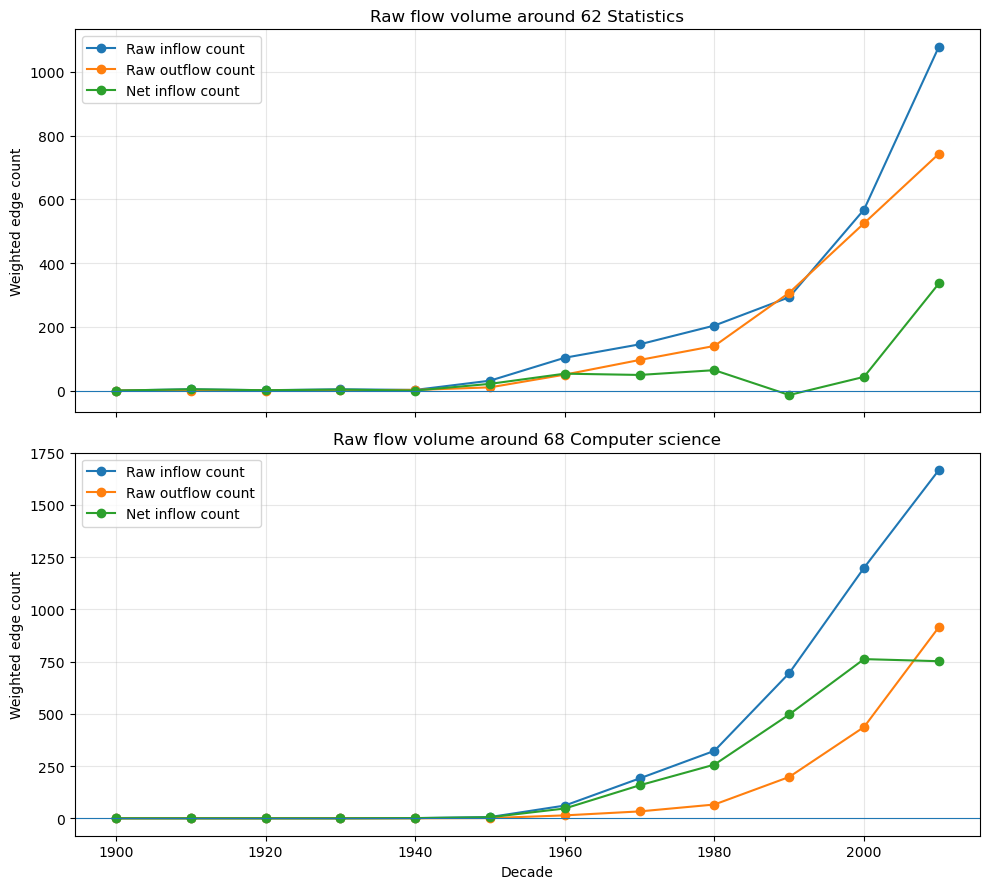

,decade,subject_label,raw_inflow_count,raw_outflow_count,net_inflow_count,same_subject_count
0,1900,62 Statistics,0.0,0.0,0.0,0.0
1,1910,62 Statistics,4.0,0.0,4.0,0.0
2,1920,62 Statistics,1.0,0.0,1.0,0.0
3,1930,62 Statistics,4.0,1.0,3.0,0.0
4,1940,62 Statistics,2.0,2.0,0.0,3.0
5,1950,62 Statistics,31.0,10.0,21.0,29.0
6,1960,62 Statistics,103.0,50.0,53.0,134.0
7,1970,62 Statistics,145.0,96.0,49.0,334.0
8,1980,62 Statistics,204.0,140.0,64.0,499.0
9,1990,62 Statistics,293.0,307.0,-14.0,861.0


In [25]:
def subject_count_timeseries(subject):
    rows = []

    for decade, summary in flow_counts_by_decade.items():
        row = summary.loc[subject]
        rows.append(
            {
                "decade": decade,
                "subject": subject,
                "subject_label": label_subject(subject),
                "raw_inflow_count": row["raw_inflow_count"],
                "raw_outflow_count": row["raw_outflow_count"],
                "net_inflow_count": row["net_inflow_count"],
                "same_subject_count": row["same_subject_count"],
                "advisor_edge_total": row["advisor_edge_total"],
                "student_edge_total": row["student_edge_total"],
            }
        )

    return pd.DataFrame(rows).sort_values("decade")


focus_count_data = pd.concat(
    [
        subject_count_timeseries(subject)
        for subject in FOCUS_SUBJECTS
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(
    nrows=len(FOCUS_SUBJECTS),
    ncols=1,
    figsize=(10, 9),
    sharex=True,
)

for axis, subject in zip(axes, FOCUS_SUBJECTS):
    subject_data = focus_count_data[
        focus_count_data["subject"].eq(subject)
    ]

    axis.plot(
        subject_data["decade"],
        subject_data["raw_inflow_count"],
        marker="o",
        label="Raw inflow count",
    )
    axis.plot(
        subject_data["decade"],
        subject_data["raw_outflow_count"],
        marker="o",
        label="Raw outflow count",
    )
    axis.plot(
        subject_data["decade"],
        subject_data["net_inflow_count"],
        marker="o",
        label="Net inflow count",
    )
    axis.axhline(0, linewidth=0.8)
    axis.set_ylabel("Weighted edge count")
    axis.set_title(
        f"Raw flow volume around {label_subject(subject)}"
    )
    axis.grid(alpha=0.3)
    axis.legend()

axes[-1].set_xlabel("Decade")
fig.tight_layout()
plt.show()

display(
    focus_count_data[
        [
            "decade",
            "subject_label",
            "raw_inflow_count",
            "raw_outflow_count",
            "net_inflow_count",
            "same_subject_count",
        ]
    ]
)

## 8. Destination and source profiles for Statistics and Computer Science

The focused subjects are:

- **62 Statistics**
- **68 Computer science**

For each subject:

- use a row of \(P_t\) for the destinations of students advised from that subject;
- use a row of \(Q_t\) for the advisor sources of students entering that subject.

The tables and heatmaps below compare the most important destinations and sources across decades.

In [26]:
def profile_table(
    decade,
    subject,
    direction,
    top_n=TOP_N_PROFILE,
    exclude_self=True,
):
    matrix = M_by_decade[decade]

    if direction == "destination":
        probabilities = (
            P_by_decade[decade]
            .loc[subject]
        )
        counts = matrix.loc[subject]
        denominator = matrix.loc[subject].sum()
        subject_column = "destination_subject"

    elif direction == "source":
        probabilities = (
            Q_by_decade[decade]
            .loc[subject]
        )
        counts = matrix[subject]
        denominator = matrix[subject].sum()
        subject_column = "source_subject"

    else:
        raise ValueError(
            "direction must be 'destination' or 'source'."
        )

    table = pd.DataFrame(
        {
            "probability": probabilities,
            "count": counts,
        }
    )

    if exclude_self:
        table = table.drop(
            subject,
            errors="ignore",
        )

    table = (
        table[
            table["count"].gt(0)
        ]
        .sort_values(
            ["probability", "count"],
            ascending=False,
        )
        .head(top_n)
        .rename_axis(subject_column)
        .reset_index()
    )

    table["subject_label"] = (
        table[subject_column]
        .map(label_subject)
    )
    table["row_support"] = denominator
    table["direction"] = direction

    return table[
        [
            "direction",
            subject_column,
            "subject_label",
            "count",
            "probability",
            "row_support",
        ]
    ]


for subject in FOCUS_SUBJECTS:
    print(
        f"\nTop destinations from "
        f"{label_subject(subject)}, "
        f"{RECENT_DECADE}s"
    )

    display(
        profile_table(
            RECENT_DECADE,
            subject,
            "destination",
        ).round(4)
    )

    print(
        f"Top advisor sources into "
        f"{label_subject(subject)}, "
        f"{RECENT_DECADE}s"
    )

    display(
        profile_table(
            RECENT_DECADE,
            subject,
            "source",
        ).round(4)
    )


Top destinations from 62 Statistics, 2010s


,direction,destination_subject,subject_label,count,probability,row_support
0,destination,91,"91 Game theory, economics, social sciences",285.0,0.0621,4586.0
1,destination,68,68 Computer science,127.0,0.0277,4586.0
2,destination,60,60 Probability theory and stochastic processes,97.0,0.0212,4586.0
3,destination,92,92 Biology and other natural sciences,83.0,0.0181,4586.0
4,destination,90,90 Operations research and mathematical progra...,56.0,0.0122,4586.0
5,destination,94,"94 Information, communication, and circuits",28.0,0.0061,4586.0
6,destination,00,00 General,11.0,0.0024,4586.0
7,destination,65,65 Numerical analysis,8.0,0.0017,4586.0
8,destination,93,93 Systems theory and control,8.0,0.0017,4586.0
9,destination,97,97 Mathematics education,8.0,0.0017,4586.0


Top advisor sources into 62 Statistics, 2010s


,direction,source_subject,subject_label,count,probability,row_support
0,source,60,60 Probability theory and stochastic processes,364.0,0.0740,4922.0
1,source,91,"91 Game theory, economics, social sciences",199.0,0.0404,4922.0
2,source,68,68 Computer science,125.0,0.0254,4922.0
3,source,92,92 Biology and other natural sciences,56.0,0.0114,4922.0
4,source,65,65 Numerical analysis,47.0,0.0095,4922.0
5,source,94,"94 Information, communication, and circuits",42.0,0.0085,4922.0
6,source,90,90 Operations research and mathematical progra...,35.0,0.0071,4922.0
7,source,93,93 Systems theory and control,23.0,0.0047,4922.0
8,source,37,37 Dynamical systems and ergodic theory,19.0,0.0039,4922.0
9,source,82,82 Statistical mechanics and structure of matter,13.0,0.0026,4922.0



Top destinations from 68 Computer science, 2010s


,direction,destination_subject,subject_label,count,probability,row_support
0,destination,62,62 Statistics,125.0,0.0164,7645.0
1,destination,94,"94 Information, communication, and circuits",119.0,0.0156,7645.0
2,destination,91,"91 Game theory, economics, social sciences",108.0,0.0141,7645.0
3,destination,90,90 Operations research and mathematical progra...,84.0,0.0110,7645.0
4,destination,92,92 Biology and other natural sciences,70.0,0.0092,7645.0
5,destination,03,03 Mathematical logic and foundations,57.0,0.0075,7645.0
6,destination,05,05 Combinatorics,49.0,0.0064,7645.0
7,destination,00,00 General,44.0,0.0058,7645.0
8,destination,65,65 Numerical analysis,42.0,0.0055,7645.0
9,destination,60,60 Probability theory and stochastic processes,39.0,0.0051,7645.0


Top advisor sources into 68 Computer science, 2010s


,direction,source_subject,subject_label,count,probability,row_support
0,source,03,03 Mathematical logic and foundations,263.0,0.0313,8397.0
1,source,94,"94 Information, communication, and circuits",257.0,0.0306,8397.0
2,source,62,62 Statistics,127.0,0.0151,8397.0
3,source,93,93 Systems theory and control,123.0,0.0146,8397.0
4,source,05,05 Combinatorics,97.0,0.0116,8397.0
5,source,60,60 Probability theory and stochastic processes,89.0,0.0106,8397.0
6,source,65,65 Numerical analysis,85.0,0.0101,8397.0
7,source,90,90 Operations research and mathematical progra...,85.0,0.0101,8397.0
8,source,92,92 Biology and other natural sciences,38.0,0.0045,8397.0
9,source,91,"91 Game theory, economics, social sciences",36.0,0.0043,8397.0


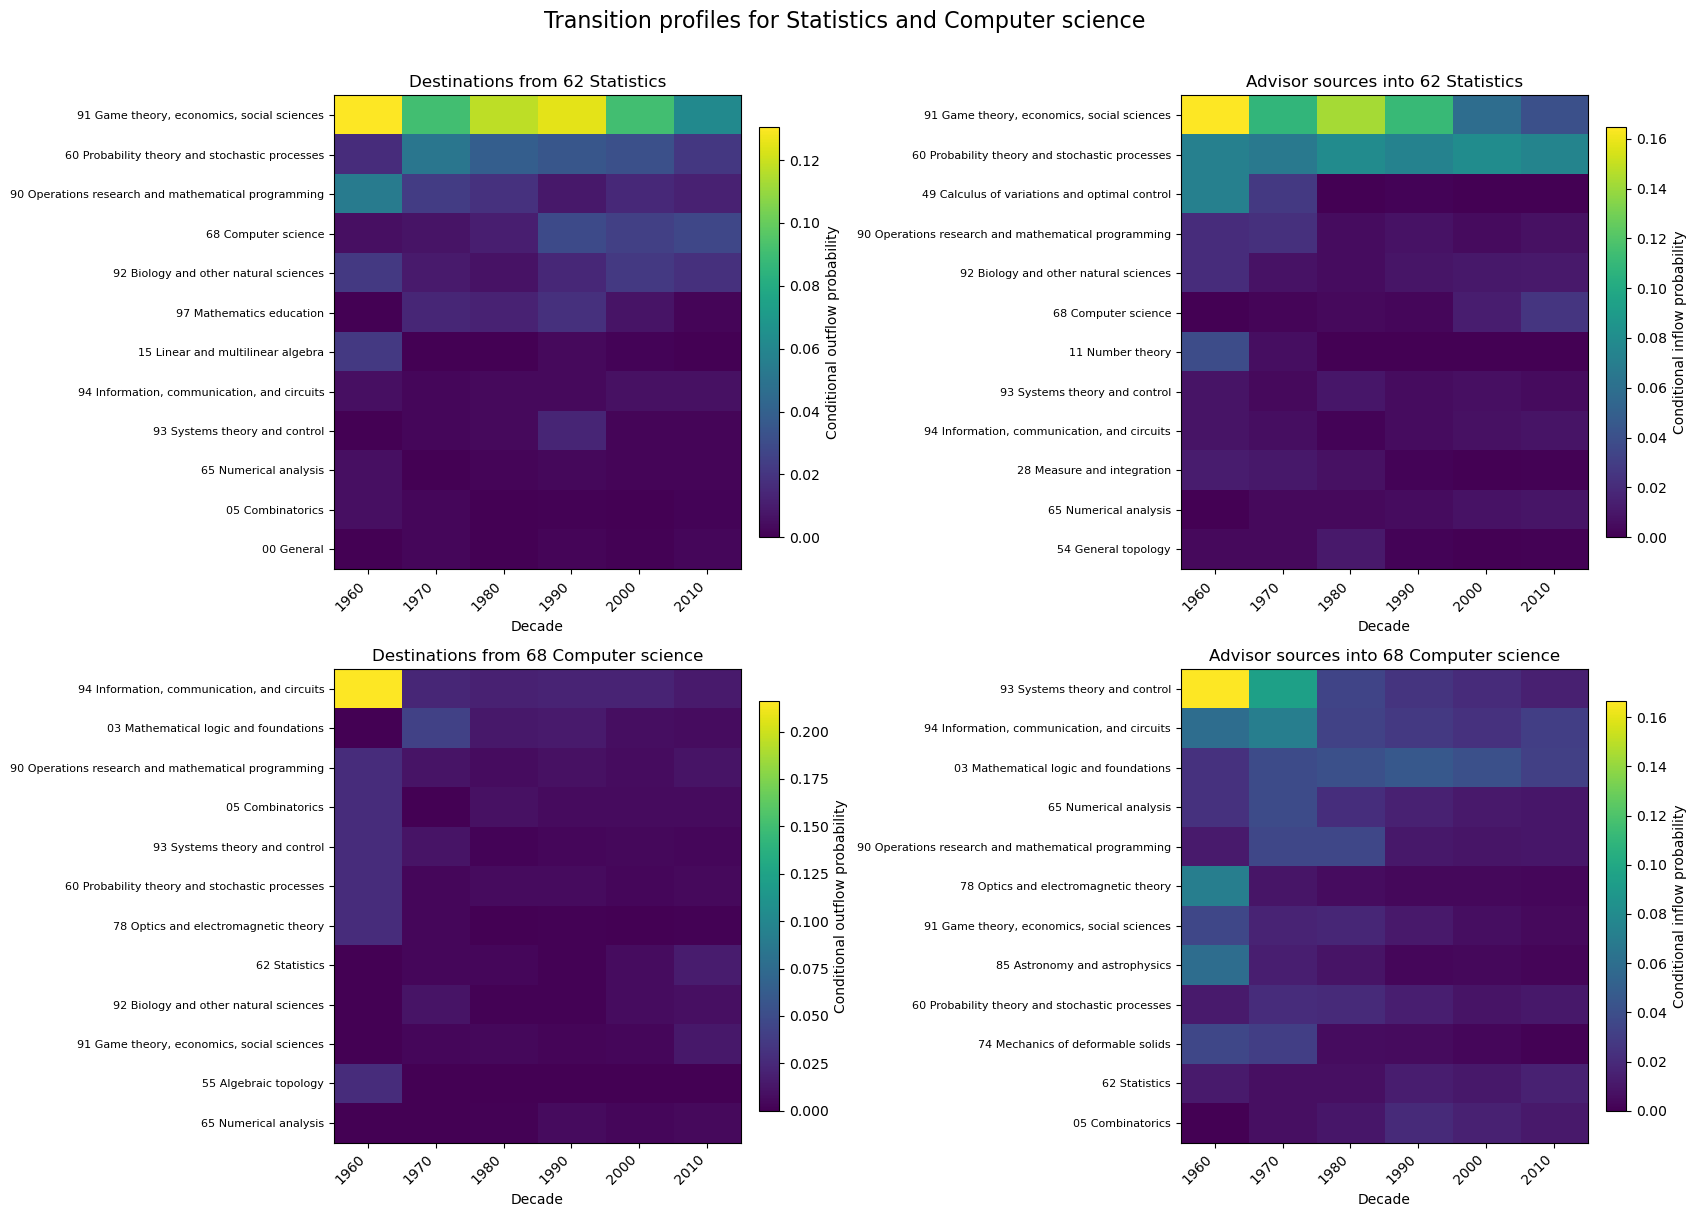

In [27]:
def probability_profile_over_time(
    matrices,
    subject,
    top_n=12,
    exclude_self=True,
):
    profile = pd.DataFrame(
        {
            decade: matrix.loc[subject]
            for decade, matrix in matrices.items()
        }
    )

    if exclude_self:
        profile = profile.drop(
            subject,
            errors="ignore",
        )

    recent_profile = profile.loc[
        :,
        DISPLAY_START_DECADE:,
    ]

    ranking = (
        recent_profile.fillna(0)
        .sum(axis=1)
        .sort_values(ascending=False)
    )

    return recent_profile.loc[
        ranking.head(top_n).index
    ]


def draw_probability_heatmap(
    axis,
    profile,
    title,
):
    plot_data = profile.fillna(0)
    labels = [
        label_subject(code)
        for code in plot_data.index
    ]

    image = axis.imshow(
        plot_data.to_numpy(),
        aspect="auto",
        vmin=0,
    )

    axis.set_xticks(
        np.arange(len(plot_data.columns))
    )
    axis.set_xticklabels(
        plot_data.columns,
        rotation=45,
        ha="right",
    )

    axis.set_yticks(
        np.arange(len(plot_data.index))
    )
    axis.set_yticklabels(
        labels,
        fontsize=8,
    )

    axis.set_xlabel("Decade")
    axis.set_title(title)

    return image


fig, axes = plt.subplots(
    nrows=len(FOCUS_SUBJECTS),
    ncols=2,
    figsize=(17, 12),
)

for row, subject in enumerate(FOCUS_SUBJECTS):
    outflow_profile = probability_profile_over_time(
        P_by_decade,
        subject,
    )

    inflow_profile = probability_profile_over_time(
        Q_by_decade,
        subject,
    )

    outflow_image = draw_probability_heatmap(
        axes[row, 0],
        outflow_profile,
        title=(
            f"Destinations from "
            f"{label_subject(subject)}"
        ),
    )

    inflow_image = draw_probability_heatmap(
        axes[row, 1],
        inflow_profile,
        title=(
            f"Advisor sources into "
            f"{label_subject(subject)}"
        ),
    )

    fig.colorbar(
        outflow_image,
        ax=axes[row, 0],
        label="Conditional outflow probability",
        fraction=0.046,
        pad=0.04,
    )

    fig.colorbar(
        inflow_image,
        ax=axes[row, 1],
        label="Conditional inflow probability",
        fraction=0.046,
        pad=0.04,
    )

fig.suptitle(
    "Transition profiles for Statistics and Computer science",
    fontsize=16,
    y=1.01,
)
fig.tight_layout()
plt.show()

## 9. Direct transitions between Statistics and Computer Science

This section isolates the two directed transitions

$$
62 \longrightarrow 68
$$

and

$$
68 \longrightarrow 62.
$$

For each decade, it reports:

- the weighted number of advisor–student edges;
- the forward conditional probability from \(P_t\);
- the backward source probability from \(Q_t\).

For example,

$$
P_t(62,68)
=
P(\text{student is in Computer science}
\mid
\text{advisor is in Statistics}),
$$

while

$$
Q_t(68,62)
=
P(\text{advisor is in Statistics}
\mid
\text{student is in Computer science}).
$$

These are different conditional questions and should not be interpreted interchangeably.

In [28]:
def focused_cross_transitions(
    left="62",
    right="68",
):
    rows = []

    for decade in DECADES:
        matrix = M_by_decade[decade]
        forward = P_by_decade[decade]
        backward = Q_by_decade[decade]

        rows.append(
            {
                "decade": decade,
                "count_62_to_68": matrix.loc[left, right],
                "count_68_to_62": matrix.loc[right, left],
                "P_62_to_68": forward.loc[left, right],
                "P_68_to_62": forward.loc[right, left],
                "Q_68_from_62": backward.loc[right, left],
                "Q_62_from_68": backward.loc[left, right],
            }
        )

    result = pd.DataFrame(rows).sort_values("decade")

    result["net_count_62_to_68"] = (
        result["count_62_to_68"]
        - result["count_68_to_62"]
    )

    return result


cross_62_68 = focused_cross_transitions()

display(cross_62_68.round(4))

,decade,count_62_to_68,count_68_to_62,P_62_to_68,P_68_to_62,Q_68_from_62,Q_62_from_68,net_count_62_to_68
0,1900,0.0,0.0,NaN,NaN,NaN,NaN,0.0
1,1910,0.0,0.0,NaN,NaN,NaN,0.0000,0.0
2,1920,0.0,0.0,NaN,NaN,NaN,0.0000,0.0
3,1930,0.0,0.0,0.0000,NaN,NaN,0.0000,0.0
4,1940,0.0,0.0,0.0000,NaN,0.0000,0.0000,0.0
5,1950,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0
6,1960,1.0,0.0,0.0054,0.0000,0.0119,0.0000,1.0
7,1970,3.0,1.0,0.0070,0.0038,0.0071,0.0021,2.0
8,1980,7.0,3.0,0.0110,0.0037,0.0066,0.0043,4.0
9,1990,34.0,3.0,0.0291,0.0014,0.0132,0.0026,31.0


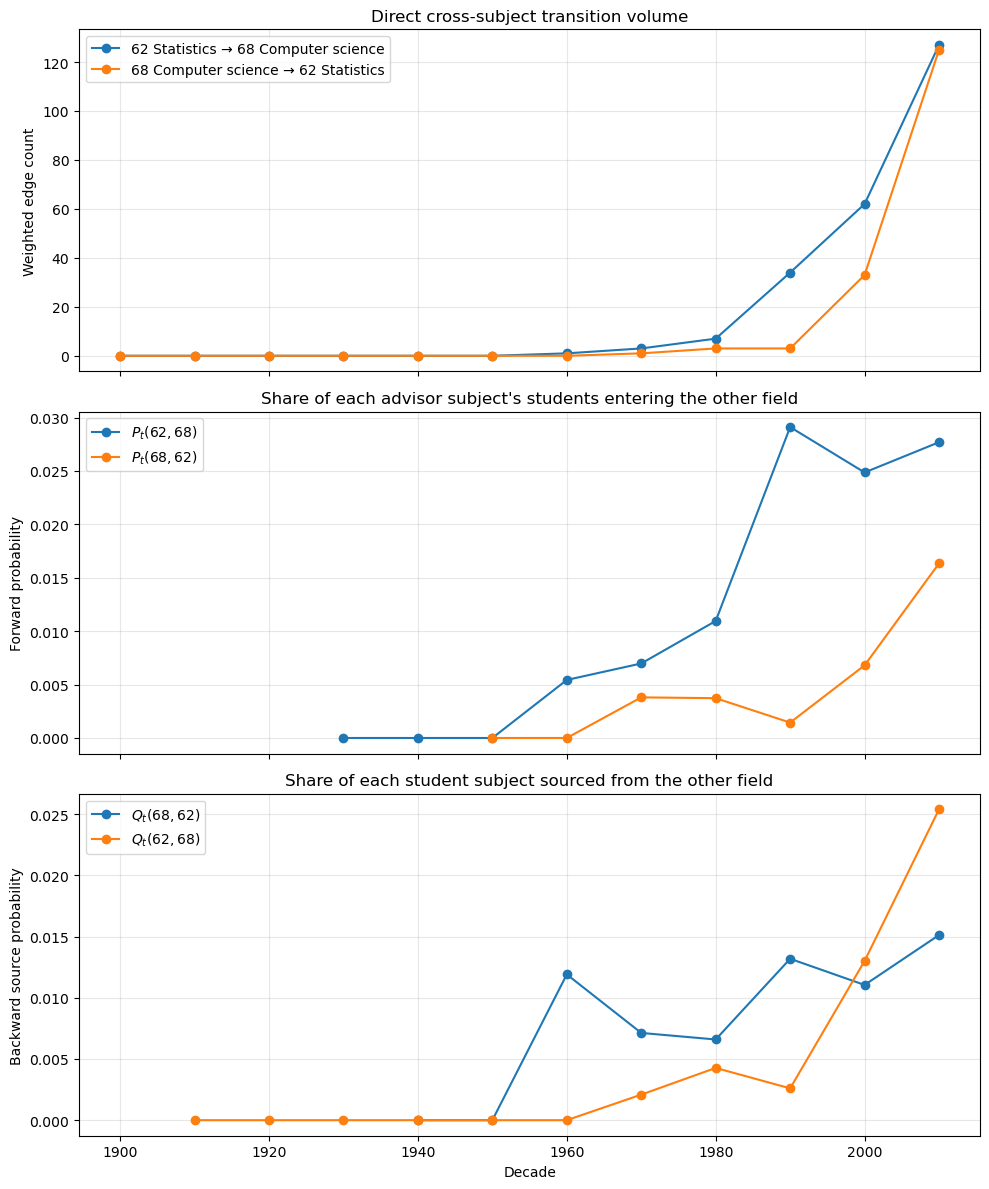

In [29]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 12),
    sharex=True,
)

axes[0].plot(
    cross_62_68["decade"],
    cross_62_68["count_62_to_68"],
    marker="o",
    label="62 Statistics → 68 Computer science",
)
axes[0].plot(
    cross_62_68["decade"],
    cross_62_68["count_68_to_62"],
    marker="o",
    label="68 Computer science → 62 Statistics",
)
axes[0].set_ylabel("Weighted edge count")
axes[0].set_title("Direct cross-subject transition volume")
axes[0].legend()

axes[1].plot(
    cross_62_68["decade"],
    cross_62_68["P_62_to_68"],
    marker="o",
    label="$P_t(62,68)$",
)
axes[1].plot(
    cross_62_68["decade"],
    cross_62_68["P_68_to_62"],
    marker="o",
    label="$P_t(68,62)$",
)
axes[1].set_ylabel("Forward probability")
axes[1].set_title(
    "Share of each advisor subject's students entering the other field"
)
axes[1].legend()

axes[2].plot(
    cross_62_68["decade"],
    cross_62_68["Q_68_from_62"],
    marker="o",
    label="$Q_t(68,62)$",
)
axes[2].plot(
    cross_62_68["decade"],
    cross_62_68["Q_62_from_68"],
    marker="o",
    label="$Q_t(62,68)$",
)
axes[2].set_xlabel("Decade")
axes[2].set_ylabel("Backward source probability")
axes[2].set_title(
    "Share of each student subject sourced from the other field"
)
axes[2].legend()

for axis in axes:
    axis.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## 10. Pure–applied transition structure

The 63 subjects are aggregated into two broad groups:

```text
Pure:    MSC codes 00–60
Applied: MSC codes 62–97
```

The resulting $2\times2$ matrices show whether students remain within the same broad basket or cross the pure/applied boundary.

In [30]:
def basket_of_subject(code):
    return (
        "Pure"
        if int(code) <= 60
        else "Applied"
    )


def basket_transition_matrix(matrix):
    groups = ["Pure", "Applied"]

    result = pd.DataFrame(
        0.0,
        index=groups,
        columns=groups,
    )

    for advisor_subject in matrix.index:
        for student_subject in matrix.columns:
            result.loc[
                basket_of_subject(
                    advisor_subject
                ),
                basket_of_subject(
                    student_subject
                ),
            ] += matrix.loc[
                advisor_subject,
                student_subject,
            ]

    return result


basket_counts_by_decade = {
    decade: basket_transition_matrix(
        matrix
    )
    for decade, matrix
    in M_by_decade.items()
}

basket_probabilities_by_decade = {
    decade: normalize_rows(matrix)
    for decade, matrix
    in basket_counts_by_decade.items()
}

basket_rows = []

for decade in DECADES:
    counts = basket_counts_by_decade[
        decade
    ]
    probabilities = (
        basket_probabilities_by_decade[
            decade
        ]
    )
    total = counts.to_numpy().sum()

    basket_rows.append(
        {
            "decade": decade,
            "pure_to_applied_probability": (
                probabilities.loc[
                    "Pure",
                    "Applied",
                ]
            ),
            "applied_to_pure_probability": (
                probabilities.loc[
                    "Applied",
                    "Pure",
                ]
            ),
            "cross_basket_edge_share": (
                (
                    counts.loc[
                        "Pure",
                        "Applied",
                    ]
                    + counts.loc[
                        "Applied",
                        "Pure",
                    ]
                ) / total
                if total > 0
                else np.nan
            ),
            "pure_to_applied_count": (
                counts.loc[
                    "Pure",
                    "Applied",
                ]
            ),
            "applied_to_pure_count": (
                counts.loc[
                    "Applied",
                    "Pure",
                ]
            ),
        }
    )

basket_transition_summary = (
    pd.DataFrame(basket_rows)
)

display(
    basket_transition_summary[
        basket_transition_summary[
            "decade"
        ].ge(DISPLAY_START_DECADE)
    ].round(4)
)

,decade,pure_to_applied_probability,applied_to_pure_probability,cross_basket_edge_share,pure_to_applied_count,applied_to_pure_count
6,1960,0.1716,0.0435,0.0817,179.0,107.0
7,1970,0.1496,0.0432,0.0798,313.0,173.0
8,1980,0.1632,0.0513,0.0864,467.0,321.0
9,1990,0.2280,0.0425,0.0943,1028.0,494.0
10,2000,0.2147,0.0480,0.1007,1936.0,938.0
11,2010,0.1846,0.0561,0.1042,3069.0,1561.0


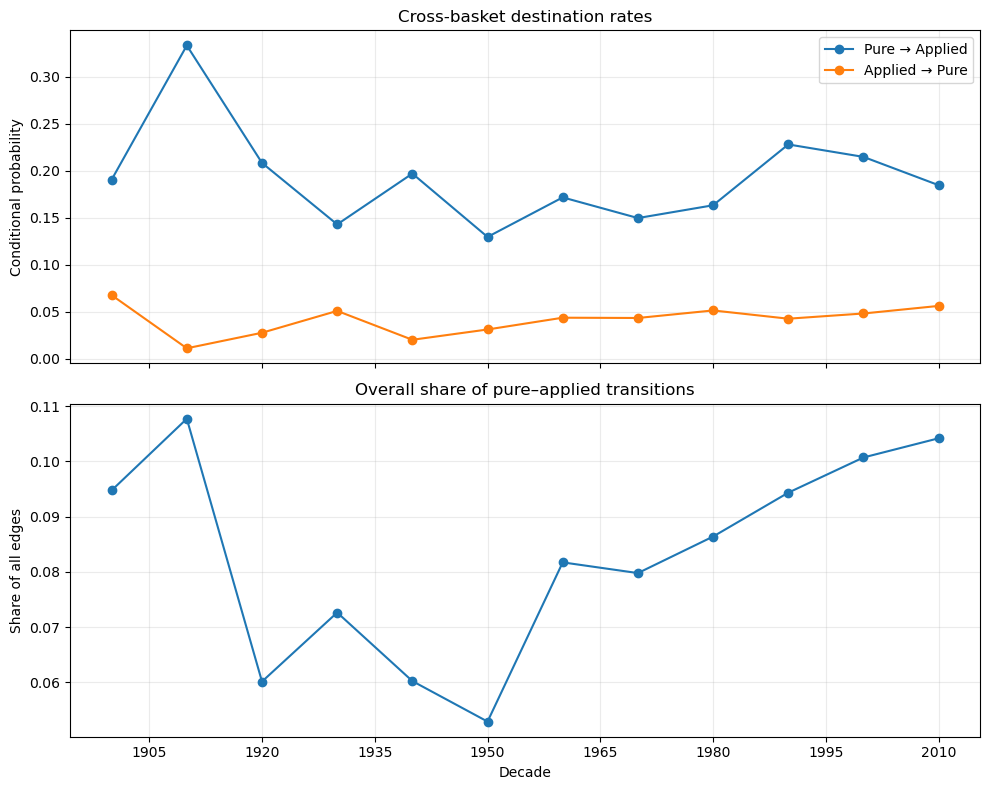

In [31]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
)

axes[0].plot(
    basket_transition_summary["decade"],
    basket_transition_summary[
        "pure_to_applied_probability"
    ],
    marker="o",
    label="Pure → Applied",
)

axes[0].plot(
    basket_transition_summary["decade"],
    basket_transition_summary[
        "applied_to_pure_probability"
    ],
    marker="o",
    label="Applied → Pure",
)

axes[0].set_ylabel(
    "Conditional probability"
)
axes[0].set_title(
    "Cross-basket destination rates"
)
axes[0].legend()

axes[1].plot(
    basket_transition_summary["decade"],
    basket_transition_summary[
        "cross_basket_edge_share"
    ],
    marker="o",
)

axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Share of all edges")
axes[1].set_title(
    "Overall share of pure–applied transitions"
)

for axis in axes:
    axis.grid(alpha=0.25)
    axis.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

fig.tight_layout()
plt.show()

## 11. Whole-network association and diversity

Observed same-subject retention is

$$
R_t
=
\frac{\sum_i M_t(i,i)}
{\sum_{i,j}M_t(i,j)}.
$$

Under independence of advisor and student subjects,

$$
R_t^{\mathrm{null}}
=
\sum_i a_i s_i,
$$

where $a_i$ and $s_i$ are the advisor- and student-subject marginal proportions.

Cohen's kappa is

$$
\kappa_t
=
\frac{
R_t-R_t^{\mathrm{null}}
}{
1-R_t^{\mathrm{null}}
}.
$$

Normalized mutual information uses the full transition table rather than only the diagonal.

Forward entropy measures the diversity of student destinations from advisor subjects. Backward entropy measures the diversity of advisor sources into student subjects. Both are weighted by their supporting edge totals and normalized by $\log(63)$.

In [32]:
def entropy(probabilities):
    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )
    probabilities = probabilities[
        np.isfinite(probabilities)
        & (probabilities > 0)
    ]

    if len(probabilities) == 0:
        return np.nan

    return float(
        -np.sum(
            probabilities
            * np.log(probabilities)
        )
    )


def weighted_row_entropy(
    probability_matrix,
    row_weights,
):
    row_entropies = (
        probability_matrix
        .apply(
            lambda row: entropy(
                row.to_numpy()
            ),
            axis=1,
        )
    )

    valid = (
        row_entropies.notna()
        & row_weights.gt(0)
    )

    return float(
        np.sum(
            row_weights[valid]
            * row_entropies[valid]
        )
    )


def decade_features(matrix):
    counts = matrix.to_numpy(dtype=float)
    total = counts.sum()

    if total <= 0:
        return {
            "observed_retention": np.nan,
            "expected_retention": np.nan,
            "excess_retention": np.nan,
            "cohens_kappa": np.nan,
            "mutual_information": np.nan,
            "normalized_mutual_information": np.nan,
            "weighted_forward_entropy": np.nan,
            "normalized_forward_entropy": np.nan,
            "weighted_backward_entropy": np.nan,
            "normalized_backward_entropy": np.nan,
        }

    joint = counts / total
    advisor_marginal = joint.sum(axis=1)
    student_marginal = joint.sum(axis=0)

    observed_retention = float(
        np.trace(joint)
    )
    expected_retention = float(
        np.sum(
            advisor_marginal
            * student_marginal
        )
    )

    denominator = 1.0 - expected_retention
    cohens_kappa = (
        (
            observed_retention
            - expected_retention
        ) / denominator
        if denominator > 0
        else np.nan
    )

    independent_joint = np.outer(
        advisor_marginal,
        student_marginal,
    )

    mask = (
        (joint > 0)
        & (independent_joint > 0)
    )

    mutual_information = float(
        np.sum(
            joint[mask]
            * np.log(
                joint[mask]
                / independent_joint[mask]
            )
        )
    )

    advisor_entropy = entropy(
        advisor_marginal
    )
    student_entropy = entropy(
        student_marginal
    )

    normalized_mi = (
        mutual_information
        / np.sqrt(
            advisor_entropy
            * student_entropy
        )
        if (
            np.isfinite(advisor_entropy)
            and np.isfinite(student_entropy)
            and advisor_entropy > 0
            and student_entropy > 0
        )
        else np.nan
    )

    advisor_weights = pd.Series(
        advisor_marginal,
        index=matrix.index,
    )
    student_weights = pd.Series(
        student_marginal,
        index=matrix.columns,
    )

    forward_entropy = weighted_row_entropy(
        forward_matrix(matrix),
        advisor_weights,
    )

    backward_entropy = weighted_row_entropy(
        backward_matrix(matrix),
        student_weights,
    )

    return {
        "observed_retention": observed_retention,
        "expected_retention": expected_retention,
        "excess_retention": (
            observed_retention
            - expected_retention
        ),
        "cohens_kappa": cohens_kappa,
        "mutual_information": mutual_information,
        "normalized_mutual_information": normalized_mi,
        "weighted_forward_entropy": forward_entropy,
        "normalized_forward_entropy": (
            forward_entropy
            / np.log(len(MSC_CODES))
        ),
        "weighted_backward_entropy": backward_entropy,
        "normalized_backward_entropy": (
            backward_entropy
            / np.log(len(MSC_CODES))
        ),
    }


feature_df = pd.DataFrame(
    {
        decade: decade_features(matrix)
        for decade, matrix in M_by_decade.items()
    }
).T

feature_df.index.name = "decade"

display(
    feature_df.loc[
        DISPLAY_START_DECADE:
    ].round(4)
)

,observed_retention,expected_retention,excess_retention,cohens_kappa,mutual_information,normalized_mutual_information,weighted_forward_entropy,normalized_forward_entropy,weighted_backward_entropy,normalized_backward_entropy
decade,,,,,,,,,,
1960,0.6149,0.0834,0.5315,0.5798,1.8788,0.5891,1.3115,0.3166,1.3093,0.3160
1970,0.6515,0.0780,0.5735,0.6220,1.9854,0.6051,1.2596,0.3040,1.3317,0.3214
1980,0.6922,0.0782,0.6140,0.6661,2.0341,0.6254,1.1845,0.2859,1.2524,0.3023
1990,0.7129,0.0914,0.6215,0.6840,1.9173,0.6137,1.1555,0.2789,1.2592,0.3039
2000,0.7182,0.0800,0.6383,0.6938,1.9224,0.6067,1.1945,0.2883,1.2992,0.3136
2010,0.7047,0.0695,0.6353,0.6827,1.9028,0.5859,1.3032,0.3146,1.3875,0.3349


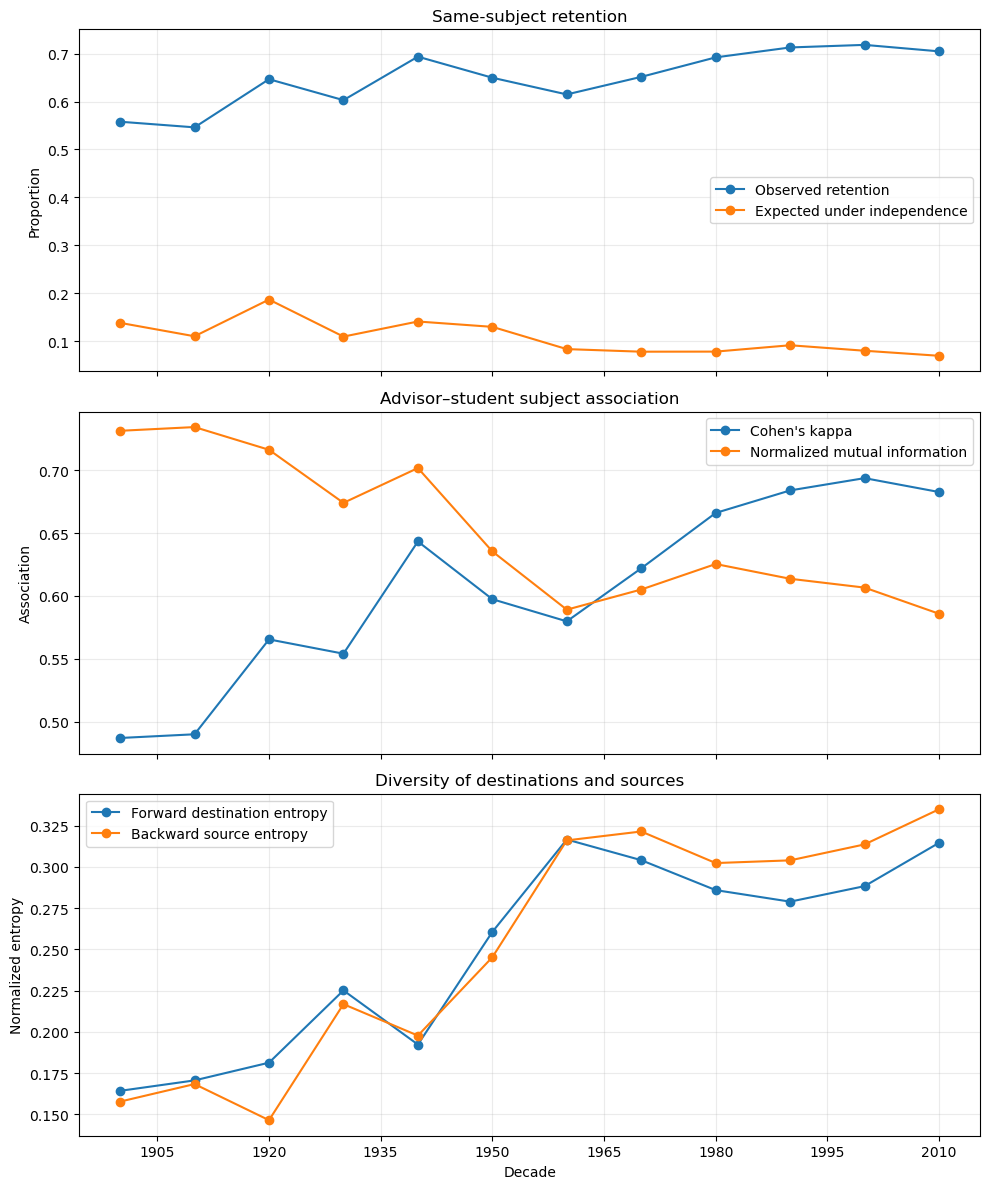

In [33]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10, 12),
    sharex=True,
)

axes[0].plot(
    feature_df.index,
    feature_df["observed_retention"],
    marker="o",
    label="Observed retention",
)
axes[0].plot(
    feature_df.index,
    feature_df["expected_retention"],
    marker="o",
    label="Expected under independence",
)
axes[0].set_ylabel("Proportion")
axes[0].set_title("Same-subject retention")
axes[0].legend()

axes[1].plot(
    feature_df.index,
    feature_df["cohens_kappa"],
    marker="o",
    label="Cohen's kappa",
)
axes[1].plot(
    feature_df.index,
    feature_df["normalized_mutual_information"],
    marker="o",
    label="Normalized mutual information",
)
axes[1].set_ylabel("Association")
axes[1].set_title("Advisor–student subject association")
axes[1].legend()

axes[2].plot(
    feature_df.index,
    feature_df["normalized_forward_entropy"],
    marker="o",
    label="Forward destination entropy",
)
axes[2].plot(
    feature_df.index,
    feature_df["normalized_backward_entropy"],
    marker="o",
    label="Backward source entropy",
)
axes[2].set_xlabel("Decade")
axes[2].set_ylabel("Normalized entropy")
axes[2].set_title("Diversity of destinations and sources")
axes[2].legend()

for axis in axes:
    axis.grid(alpha=0.25)
    axis.xaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

fig.tight_layout()
plt.show()

## 12. Transitions stronger than expected under independence

For cell $(i,j)$, the independence-model expected count is

$$
E_{ij}
=
\frac{
(\text{advisor total}_i)
(\text{student total}_j)
}{
\text{all edges}
}.
$$

The Pearson residual is

$$
r_{ij}
=
\frac{
M_{ij}-E_{ij}
}{
\sqrt{E_{ij}}
}.
$$

Large positive off-diagonal residuals identify transitions that are stronger than expected after accounting for the overall sizes of the advisor and student subjects.

In [34]:
def pearson_residual_table(
    matrix,
    top_n=20,
    minimum_expected=5,
):
    observed = matrix.to_numpy(
        dtype=float
    )
    total = observed.sum()

    row_totals = observed.sum(axis=1)
    column_totals = observed.sum(axis=0)

    expected = np.outer(
        row_totals,
        column_totals,
    ) / total

    with np.errstate(
        divide="ignore",
        invalid="ignore",
    ):
        residual = (
            observed - expected
        ) / np.sqrt(expected)

    records = []

    for row_index, advisor_subject in enumerate(
        matrix.index
    ):
        for column_index, student_subject in enumerate(
            matrix.columns
        ):
            if advisor_subject == student_subject:
                continue

            if expected[
                row_index,
                column_index,
            ] < minimum_expected:
                continue

            records.append(
                {
                    "advisor_subject": advisor_subject,
                    "student_subject": student_subject,
                    "observed_count": observed[
                        row_index,
                        column_index,
                    ],
                    "expected_count": expected[
                        row_index,
                        column_index,
                    ],
                    "pearson_residual": residual[
                        row_index,
                        column_index,
                    ],
                }
            )

    result = pd.DataFrame(records)

    result["advisor_label"] = (
        result["advisor_subject"]
        .map(label_subject)
    )
    result["student_label"] = (
        result["student_subject"]
        .map(label_subject)
    )

    return (
        result.sort_values(
            "pearson_residual",
            ascending=False,
        )
        .head(top_n)
        .reset_index(drop=True)
    )


stronger_than_expected = (
    pearson_residual_table(
        M_by_decade[RECENT_DECADE]
    )
)

display(
    stronger_than_expected[
        [
            "advisor_label",
            "student_label",
            "observed_count",
            "expected_count",
            "pearson_residual",
        ]
    ].round(3)
)

,advisor_label,student_label,observed_count,expected_count,pearson_residual
0,46 Functional analysis,47 Operator theory,77.0,6.278,28.226
1,47 Operator theory,46 Functional analysis,70.0,6.309,25.358
2,81 Quantum theory,83 Relativity and gravitational theory,63.0,6.032,23.194
3,52 Convex and discrete geometry,05 Combinatorics,58.0,6.768,19.692
4,34 Ordinary differential equations,37 Dynamical systems and ergodic theory,39.0,6.072,13.363
5,49 Calculus of variations and optimal control,35 Partial differential equations,51.0,11.197,11.895
6,93 Systems theory and control,49 Calculus of variations and optimal control,34.0,6.777,10.457
7,34 Ordinary differential equations,35 Partial differential equations,49.0,12.690,10.193
8,20 Group theory,16 Associative rings and algebras,37.0,8.742,9.558
9,37 Dynamical systems and ergodic theory,92 Biology and other natural sciences,58.0,19.641,8.655


## 13. Largest probability changes from the 2000s to the 2010s

A change in $P_t(i,j)$ describes a shift in the destination distribution of advisor subject $i$.

A change in $Q_t(j,i)$ describes a shift in the source distribution of student subject $j$.

Rows must have at least 50 supporting edges in both decades.

In [35]:
def probability_change_table(
    earlier,
    later,
    direction,
    top_n=15,
    minimum_row_support=50,
):
    if direction == "forward":
        earlier_matrix = P_by_decade[
            earlier
        ]
        later_matrix = P_by_decade[
            later
        ]
        earlier_support = (
            M_by_decade[earlier]
            .sum(axis=1)
        )
        later_support = (
            M_by_decade[later]
            .sum(axis=1)
        )
        row_role = "advisor_subject"
        column_role = "student_subject"

    elif direction == "backward":
        earlier_matrix = Q_by_decade[
            earlier
        ]
        later_matrix = Q_by_decade[
            later
        ]
        earlier_support = (
            M_by_decade[earlier]
            .sum(axis=0)
        )
        later_support = (
            M_by_decade[later]
            .sum(axis=0)
        )
        row_role = "student_subject"
        column_role = "advisor_subject"

    else:
        raise ValueError(
            "direction must be "
            "'forward' or 'backward'."
        )

    change = (
        later_matrix - earlier_matrix
    )

    records = []

    for row_subject in change.index:
        if (
            earlier_support.loc[row_subject]
            < minimum_row_support
            or later_support.loc[row_subject]
            < minimum_row_support
        ):
            continue

        for column_subject in change.columns:
            if row_subject == column_subject:
                continue

            value = change.loc[
                row_subject,
                column_subject,
            ]

            if pd.notna(value):
                records.append(
                    {
                        row_role: row_subject,
                        column_role: column_subject,
                        "probability_change": value,
                        "earlier_probability": (
                            earlier_matrix.loc[
                                row_subject,
                                column_subject,
                            ]
                        ),
                        "later_probability": (
                            later_matrix.loc[
                                row_subject,
                                column_subject,
                            ]
                        ),
                        "earlier_row_support": (
                            earlier_support.loc[
                                row_subject
                            ]
                        ),
                        "later_row_support": (
                            later_support.loc[
                                row_subject
                            ]
                        ),
                    }
                )

    result = pd.DataFrame(records)

    for column in [
        row_role,
        column_role,
    ]:
        result[
            f"{column}_label"
        ] = result[column].map(
            label_subject
        )

    increases = (
        result.nlargest(
            top_n,
            "probability_change",
        )
        .assign(
            change_direction="increase"
        )
    )

    decreases = (
        result.nsmallest(
            top_n,
            "probability_change",
        )
        .assign(
            change_direction="decrease"
        )
    )

    return pd.concat(
        [increases, decreases],
        ignore_index=True,
    )


forward_changes = probability_change_table(
    2000,
    2010,
    "forward",
)

backward_changes = probability_change_table(
    2000,
    2010,
    "backward",
)

print("Largest forward destination changes")
display(forward_changes.round(4))

print("Largest backward source changes")
display(backward_changes.round(4))

Largest forward destination changes


,advisor_subject,student_subject,probability_change,earlier_probability,later_probability,earlier_row_support,later_row_support,advisor_subject_label,student_subject_label,change_direction
0,52,05,0.1177,0.1200,0.2377,100.0,244.0,52 Convex and discrete geometry,05 Combinatorics,increase
1,06,00,0.1122,0.0000,0.1122,69.0,98.0,"06 Order, lattices, ordered algebra",00 General,increase
2,58,53,0.0839,0.1765,0.2604,68.0,169.0,58 Global analysis,53 Differential geometry,increase
3,43,35,0.0829,0.0260,0.1089,77.0,101.0,43 Abstract harmonic analysis,35 Partial differential equations,increase
4,17,05,0.0643,0.0000,0.0643,74.0,171.0,17 Nonassociative rings and algebras,05 Combinatorics,increase
5,08,68,0.0614,0.1636,0.2250,55.0,80.0,08 General algebraic systems,68 Computer science,increase
6,47,46,0.0609,0.1111,0.1720,207.0,407.0,47 Operator theory,46 Functional analysis,increase
7,82,60,0.0574,0.0490,0.1064,306.0,376.0,82 Statistical mechanics and structure of matter,60 Probability theory and stochastic processes,increase
8,00,93,0.0560,0.1940,0.2500,67.0,92.0,00 General,93 Systems theory and control,increase
9,49,35,0.0553,0.1066,0.1619,244.0,315.0,49 Calculus of variations and optimal control,35 Partial differential equations,increase


Largest backward source changes


,student_subject,advisor_subject,probability_change,earlier_probability,later_probability,earlier_row_support,later_row_support,student_subject_label,advisor_subject_label,change_direction
0,78,68,0.0924,0.0000,0.0924,147.0,119.0,78 Optics and electromagnetic theory,68 Computer science,increase
1,51,53,0.0873,0.0722,0.1595,97.0,163.0,51 Geometry,53 Differential geometry,increase
2,78,94,0.0752,0.0340,0.1092,147.0,119.0,78 Optics and electromagnetic theory,"94 Information, communication, and circuits",increase
3,00,68,0.0721,0.1288,0.2009,132.0,219.0,00 General,68 Computer science,increase
4,32,55,0.0631,0.0125,0.0756,80.0,119.0,32 Several complex variables,55 Algebraic topology,increase
5,49,93,0.0612,0.0657,0.1269,198.0,268.0,49 Calculus of variations and optimal control,93 Systems theory and control,increase
6,01,11,0.0567,0.0526,0.1094,57.0,64.0,01 History and biography,11 Number theory,increase
7,92,37,0.0504,0.0068,0.0572,588.0,1014.0,92 Biology and other natural sciences,37 Dynamical systems and ergodic theory,increase
8,00,06,0.0502,0.0000,0.0502,132.0,219.0,00 General,"06 Order, lattices, ordered algebra",increase
9,18,16,0.0498,0.0877,0.1376,57.0,189.0,18 Category theory and homological algebra,16 Associative rings and algebras,increase


## 14. Spectral summary

Eigenvalues are reported only when every row of the probability matrix is supported and the matrix is genuinely row-stochastic.

For such a matrix,

$$
|\lambda_1|=1.
$$

The second-largest eigenvalue modulus and spectral gap are

$$
|\lambda_2|,
\qquad
1-|\lambda_2|.
$$

A small gap indicates slow mixing or nearly separated groups **under hypothetical repeated use of one decade's matrix**. It does not justify multiplying matrices from different historical decades.

This fixes a problem in the earlier notebook, where unsupported rows were replaced by zeros before interpretation.

In [36]:
def spectral_summary(matrices):
    rows = []

    for decade, matrix in matrices.items():
        row_sums = matrix.sum(
            axis=1,
            min_count=1,
        )

        zero_rows = int(
            row_sums.isna().sum()
        )

        row = {
            "decade": decade,
            "zero_rows": zero_rows,
            "spectral_radius": np.nan,
            "lambda_2_modulus": np.nan,
            "spectral_gap": np.nan,
            "eigenvalues_near_one": np.nan,
        }

        if zero_rows == 0:
            values = matrix.to_numpy(
                dtype=float
            )

            if np.allclose(
                values.sum(axis=1),
                1.0,
            ):
                eigenvalues = (
                    np.linalg.eigvals(
                        values
                    )
                )

                moduli = np.sort(
                    np.abs(eigenvalues)
                )[::-1]

                row["spectral_radius"] = (
                    moduli[0]
                )
                row["lambda_2_modulus"] = (
                    moduli[1]
                    if len(moduli) > 1
                    else np.nan
                )
                row["spectral_gap"] = (
                    1 - moduli[1]
                    if len(moduli) > 1
                    else np.nan
                )
                row[
                    "eigenvalues_near_one"
                ] = int(
                    np.isclose(
                        moduli,
                        1.0,
                        atol=1e-6,
                    ).sum()
                )

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .set_index("decade")
        .sort_index()
    )


spectral_P = spectral_summary(
    P_by_decade
)
spectral_Q = spectral_summary(
    Q_by_decade
)

spectral_comparison = pd.concat(
    {
        "P_forward": spectral_P,
        "Q_backward": spectral_Q,
    },
    axis=1,
)

display(
    spectral_comparison.loc[
        DISPLAY_START_DECADE:
    ].round(4)
)

P_forward                                                \
       zero_rows spectral_radius lambda_2_modulus spectral_gap   
decade                                                           
1960           3             NaN              NaN          NaN   
1970           0             1.0           0.9348       0.0652   
1980           0             1.0           0.9658       0.0342   
1990           0             1.0           0.9466       0.0534   
2000           0             1.0           0.9436       0.0564   
2010           0             1.0           0.9488       0.0512   

                            Q_backward                                   \
       eigenvalues_near_one  zero_rows spectral_radius lambda_2_modulus   
decade                                                                    
1960                    NaN          3             NaN              NaN   
1970                    1.0          1             NaN              NaN   
1980                    1.0          0             1.0           0.9980   
1990                    1.0          0             1.0           0.9330   
2000                    1.0          0             1.0           0.9195   
2010                    1.0          0             1.0           0.9008   

                                          
       spectral_gap eigenvalues_near_one  
decade                                    
1960            NaN                  NaN  
1970            NaN                  NaN  
1980         0.0020                  1.0  
1990         0.0670                  1.0  
2000         0.0805                  1.0  
2010         0.0992                  1.0

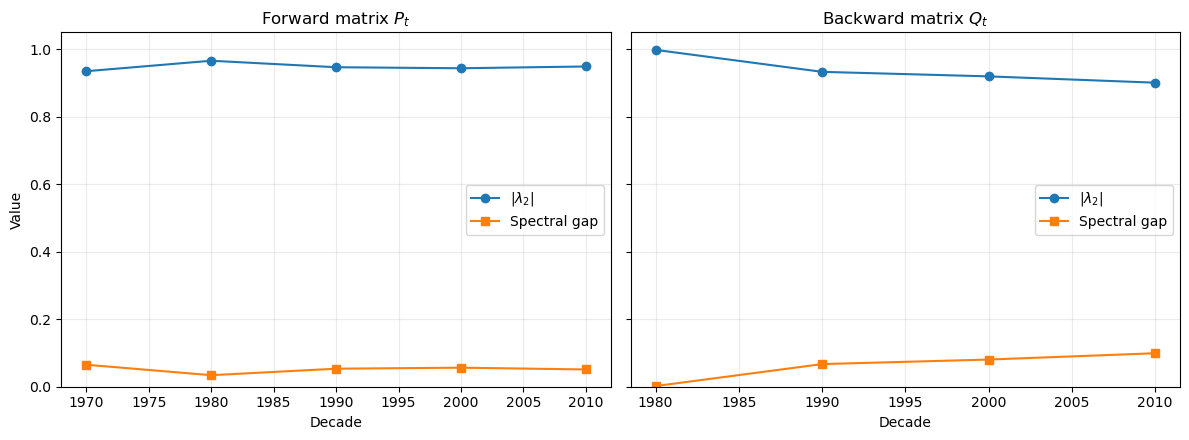

In [37]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
    sharey=True,
)

axes[0].plot(
    spectral_P.index,
    spectral_P["lambda_2_modulus"],
    marker="o",
    label="$|\\lambda_2|$",
)
axes[0].plot(
    spectral_P.index,
    spectral_P["spectral_gap"],
    marker="s",
    label="Spectral gap",
)
axes[0].set_title(
    "Forward matrix $P_t$"
)

axes[1].plot(
    spectral_Q.index,
    spectral_Q["lambda_2_modulus"],
    marker="o",
    label="$|\\lambda_2|$",
)
axes[1].plot(
    spectral_Q.index,
    spectral_Q["spectral_gap"],
    marker="s",
    label="Spectral gap",
)
axes[1].set_title(
    "Backward matrix $Q_t$"
)

axes[0].set_ylabel("Value")

for axis in axes:
    axis.set_xlabel("Decade")
    axis.set_ylim(0, 1.05)
    axis.grid(alpha=0.25)
    axis.legend()

fig.tight_layout()
plt.show()

## 15. Long-form tables for later modeling

These tables are convenient inputs for confidence intervals, permutation tests, bootstrap analyses, or regression models.

In [38]:
def rates_to_long():
    rows = []

    for decade in DECADES:
        matrix = M_by_decade[decade]
        counts = flow_counts_by_decade[decade]

        for subject in MSC_CODES:
            rows.append(
                {
                    "decade": decade,
                    "subject": subject,
                    "subject_label": label_subject(subject),
                    "basket": basket_of_subject(subject),
                    "forward_retention": (
                        forward_retention_df.loc[
                            decade,
                            subject,
                        ]
                    ),
                    "outflow_rate": (
                        outflow_rate_df.loc[
                            decade,
                            subject,
                        ]
                    ),
                    "same_subject_ancestry": (
                        same_subject_ancestry_df.loc[
                            decade,
                            subject,
                        ]
                    ),
                    "inflow_rate": (
                        inflow_rate_df.loc[
                            decade,
                            subject,
                        ]
                    ),
                    **counts.loc[subject].to_dict(),
                }
            )

    return pd.DataFrame(rows)


subject_rate_long = rates_to_long()

display(subject_rate_long.head())

,decade,subject,subject_label,basket,forward_retention,outflow_rate,same_subject_ancestry,inflow_rate,raw_inflow_count,raw_outflow_count,net_inflow_count,same_subject_count,advisor_edge_total,student_edge_total
0,1900,00,00 General,Pure,0.500000,0.500000,0.500000,0.500000,1.0,1.0,0.0,1.0,2.0,2.0
1,1900,01,01 History and biography,Pure,0.666667,0.333333,0.666667,0.333333,1.0,1.0,0.0,2.0,3.0,3.0
2,1900,03,03 Mathematical logic and foundations,Pure,NaN,NaN,0.000000,1.000000,3.0,0.0,3.0,0.0,0.0,3.0
3,1900,05,05 Combinatorics,Pure,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
4,1900,06,"06 Order, lattices, ordered algebra",Pure,NaN,NaN,0.000000,1.000000,1.0,0.0,1.0,0.0,0.0,1.0


## Interpretation summary

- Use $P_t$ for **forward destination** questions:

  $$
  P_t(i,j)
  =
  P(S=j\mid A=i).
  $$

- Use $Q_t$ for **backward source** questions:

  $$
  Q_t(j,i)
  =
  P(A=i\mid S=j).
  $$

- Use $M_t$ for raw transition counts.

- Interpret probabilities together with their advisor-row or student-row support.

- Do not interpret unsupported rows as 100% movement; their conditional distributions are undefined.

- The focused Statistics–Computer science analysis separates raw counts, forward probabilities, and backward probabilities because these quantities use different denominators.

- Pure–applied aggregation gives a broad summary of cross-basket movement but does not replace the 63-subject transition analysis.

- Cohen's kappa and normalized mutual information measure advisor–student association beyond changing marginal subject frequencies.

- Pearson residuals identify cross-subject transitions stronger than expected after accounting for the sizes of both subjects.

- The spectral section is optional. It only analyzes fully supported row-stochastic matrices under a hypothetical repeated-transition interpretation; it does not justify multiplying historical decade matrices.